### TIP Longitudinal analysis

In [317]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [318]:
### Load samplesheet
samplesheet = 'cf_longitudinal_samplesheet.csv'
tip_samplesheet = pl.read_csv(samplesheet).filter(pl.col('bioproject') == 'PRJNA530252')

In [320]:
### Load TIP data
tip_data_dir = '../../../results/uhvdb/analyze/prjna530252/SRR*/*/sylph/profile/*.profile.tsv'
tip_df_lst = []

for file in glob.glob(tip_data_dir):
    sample_id = file.split('/')[-4]
    df = (
        pl.read_csv(file, separator='\t')
            .with_columns([
                pl.lit(sample_id).alias('sample'),
                pl.col('Contig_name').str.split(' ').list[0].alias('contig')
            ])
            [['sample', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'True_cov', 'contig']]
    )
    tip_df_lst.append(df)
tip_df = pl.concat(tip_df_lst)

### Merge TIP data with samplesheet
tip_merged = tip_df.join(tip_samplesheet[['sample', 'coassembly_group', 'condition', 'timepoint']], on='sample')

In [322]:
### merge activity data
activity_data = pl.read_csv('../figure_6/cf_metagenome_virus_activity_data.tsv', separator='\t')
tip_activity_merged = (
    tip_merged
        .join(activity_data[['sample_id', 'breadth_ratio', 'contig_id', 'activity_score', 'mvirs_score', 'propagate_score', 'dtr_score']]
            .rename({'sample_id': 'sample', 'contig_id': 'contig'}),
        on=['sample', 'contig'], how='left')
)

In [323]:
### merge host genus predictions
host_preds = pl.read_csv('../figure_6/uhvdb_r2025_10_species_combined_host_predictions.tsv', separator='\t')

tip_activity_host= (
    tip_activity_merged
        .join(host_preds[['votu_rep', 'species', 'genus', 'family']],
            left_on=['contig'], right_on=['votu_rep'], how='left'
        )
)

In [324]:
### load host taxonomy
glob_genus = (
    pl.read_csv('../figure_6/globdb_r226_taxonomy.tsv.gz', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_2').str.split(';').list[5].alias('bac_genus'),
            pl.col('column_1').alias('genome_id')
        ])
        .with_columns([
            pl.col('bac_genus').str.replace('g__', '')
        ])
        [['bac_genus', 'genome_id']]
)

tip_activity_glob = (
    tip_activity_host
        .with_columns([
            pl.col('Genome_file').str.split('/').list[-1].str.split('.').list[0].alias('genome_id')
        ])
        .join(glob_genus, on='genome_id', how='left')
        [['sample', 'timepoint', 'coassembly_group', 'genome_id', 'contig', 'breadth_ratio', 'activity_score', 'mvirs_score', 'dtr_score', 'propagate_score', 'genus', 'bac_genus', 'True_cov', 'Sequence_abundance', 'Taxonomic_abundance']]
)


In [325]:
# display up to 20 rows in polars
pl.Config.set_tbl_rows(20)

tip_clinical_data = pl.read_csv('tip_clinical.tsv', separator='\t', null_values='NA')
tip_clinical_data
responder = set(
    tip_clinical_data
        .with_columns([
            (pl.lit('N') + pl.col('Pt').cast(pl.String)).alias('sample_id')
        ]).filter(pl.col('FEV_Change') > 0)
        ['sample_id']
)

non_responder = set(
    tip_clinical_data
        .with_columns([
            (pl.lit('N') + pl.col('Pt').cast(pl.String)).alias('sample_id')
        ]).filter(pl.col('FEV_Change') < 0)
        ['sample_id']
)

tip_activity_glob = (
    tip_activity_glob
        .with_columns([
            pl.when(pl.col('coassembly_group').is_in(responder)).then(pl.lit('Responder'))
                .otherwise(pl.lit('Non-responder'))
                .alias('clinical_category')
        ])
)

In [326]:
groups_w_all = set(
    tip_activity_glob
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['coassembly_group'])
        .agg(pl.col('timepoint').n_unique().alias('num_timepoints'))
        .filter(pl.col('num_timepoints') == 6)
        ['coassembly_group']
)

tip_tbl = (
    pl.read_csv('tip_tbl.tsv', separator='\t', null_values='NA')
        .filter(pl.col('Sample').str.starts_with('N'))
        .filter(pl.col('Sample').str.contains(r'.*S\d+'))
        .with_columns([
            pl.col('Sample').str.split('S').list[0].alias('coassembly_group'),
            pl.col('Sample').str.split('S').list[-1].alias('timepoint'),
        ])
        .filter(pl.col('timepoint').is_in(['0', '1']))
        # .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .sort(by=['timepoint'])
        .group_by('coassembly_group', maintain_order=True)
        .agg([
            pl.col('TBL').head(2), # select timepoint 0 then select timepoint 1
            pl.len()
        ])
        .filter(pl.col('len') == 2)
        .with_columns([
            (pl.col('TBL').list.get(0) / pl.col('TBL').list.get(1)).alias('TBL ratio'),
        ])
)

tip_activity_glob = (
    tip_activity_glob
        .join(tip_tbl[['coassembly_group', 'TBL ratio']], on=['coassembly_group'], how='left')
)

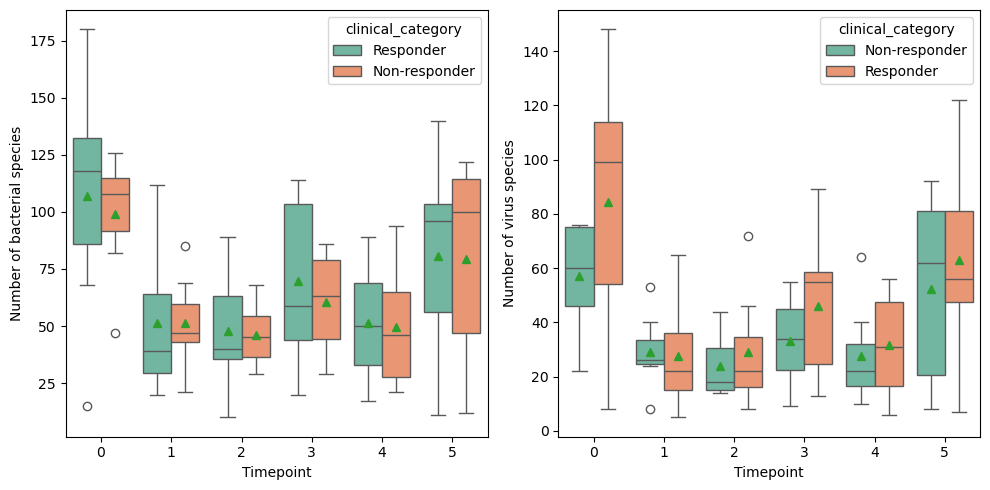

In [327]:
### Plot viral and bacterial genus richness by clinical category
groups_w_all = set(
    tip_activity_glob
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['coassembly_group'])
        .agg(pl.col('timepoint').n_unique().alias('num_timepoints'))
        .filter(pl.col('num_timepoints') == 6)
        ['coassembly_group']
)

# Bacterial species richness per sample
bac_richness = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3' ,'4' ,'5']))
        .filter(~pl.col('genome_id').str.starts_with('uhvdb'))
        .group_by(['sample', 'coassembly_group', 'clinical_category', 'timepoint'])
        .agg(pl.col('genome_id').n_unique().alias('richness'))
        .with_columns(pl.lit('Bacteria').alias('Type'))
)

# Viral richness per sample (genomes with breadth >= 0.6)
virus_richness = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3' ,'4' ,'5']))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .group_by(['sample', 'coassembly_group', 'clinical_category', 'timepoint'])
        .agg(pl.col('contig').n_unique().alias('richness'))
        .with_columns(pl.lit('Viruses').alias('Type'))
)

# Combine data
richness_df = pl.concat([bac_richness, virus_richness]).to_pandas()

# Plot side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Bacterial richness
bac_data = richness_df[richness_df['Type'] == 'Bacteria']
sns.boxplot(data=bac_data.sort_values('timepoint'), x='timepoint', y='richness', hue='clinical_category',palette='Set2', ax=axes[0], showmeans=True)
axes[0].set_xlabel('Timepoint')
axes[0].set_ylabel('Number of bacterial species')

# Viral richness
virus_data = richness_df[richness_df['Type'] == 'Viruses']
sns.boxplot(data=virus_data.sort_values('timepoint'), x='timepoint', y='richness', hue='clinical_category', palette='Set2', ax=axes[1], showmeans=True)
axes[1].set_xlabel('Timepoint')
axes[1].set_ylabel('Number of virus species')

plt.tight_layout()
plt.show()

/tmp/ipykernel_89431/2636952293.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


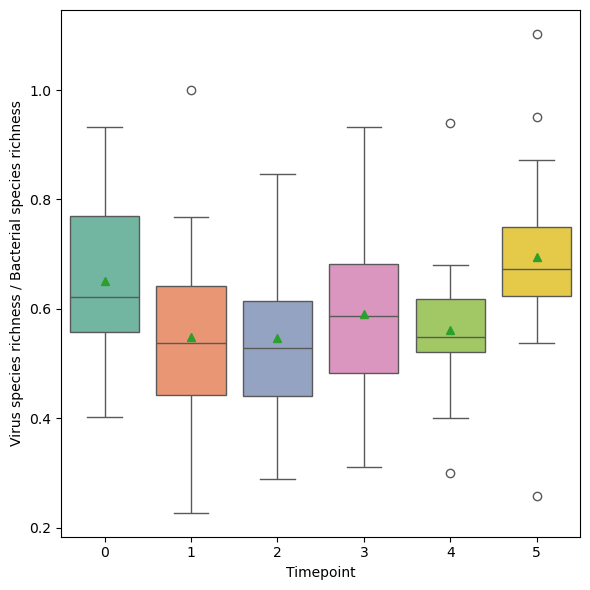

In [328]:
### Plot virus-to-bacteria species richness ratio by timepoint and responder type

# Bacterial species richness per sample/timepoint (exclude uhvdb genomes)
bac_richness_tp = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .filter(~pl.col('genome_id').str.starts_with('uhvdb'))
        .group_by(['sample', 'coassembly_group', 'clinical_category', 'timepoint'])
        .agg(pl.col('genome_id').n_unique().alias('bac_richness'))
)

# Viral species richness per sample/timepoint (breadth >= 0.6)
virus_richness_tp = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .group_by(['sample', 'coassembly_group', 'clinical_category', 'timepoint'])
        .agg(pl.col('contig').n_unique().alias('virus_richness'))
)

# Join and compute ratio
richness_ratio = (
    bac_richness_tp
        .join(virus_richness_tp, on=['sample', 'coassembly_group', 'clinical_category', 'timepoint'], how='inner')
        .with_columns(
            (pl.col('virus_richness') / pl.col('bac_richness')).alias('virus_to_bacteria_richness_ratio')
        )
        .to_pandas()
)

# Plot ratio by timepoint, colored by responder type
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=richness_ratio.sort_values('timepoint'),
    x='timepoint',
    y='virus_to_bacteria_richness_ratio',
    # hue='clinical_category',
    order=['0', '1', '2', '3', '4', '5'],
    palette='Set2',
    showmeans=True
)
plt.xlabel('Timepoint')
plt.ylabel('Virus species richness / Bacterial species richness')
plt.tight_layout()
plt.show()


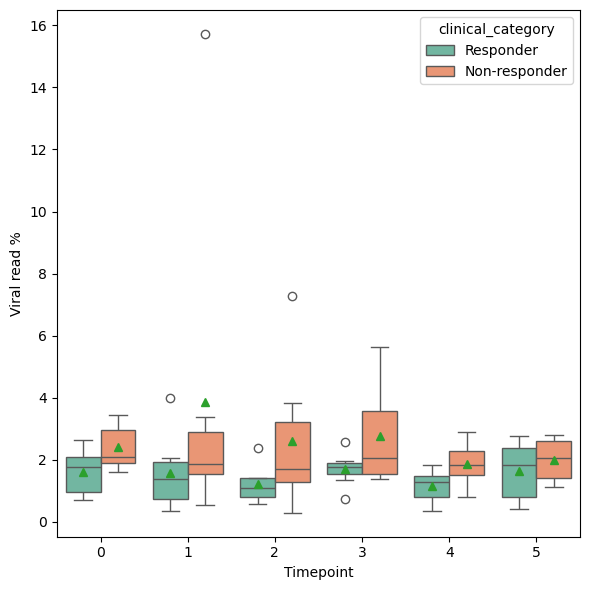

In [330]:
### Proportion of reads aligning to viruses by timepoint and clinical response

# Viral sequence abundance per sample/timepoint
abundance_viral = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .group_by(['sample', 'coassembly_group', 'clinical_category', 'timepoint'])
        .agg(pl.col('Sequence_abundance').sum().alias('viral_sequence_abundance'))
        .to_pandas()
)


# Plot proportion by timepoint and responder status
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=abundance_viral.sort_values('timepoint'),
    x='timepoint',
    y='viral_sequence_abundance',
    hue='clinical_category',
    order=['0', '1', '2', '3', '4', '5'],
    palette='Set2',
    showmeans=True
)
plt.xlabel('Timepoint')
plt.ylabel('Viral read %')
plt.tight_layout()
plt.show()


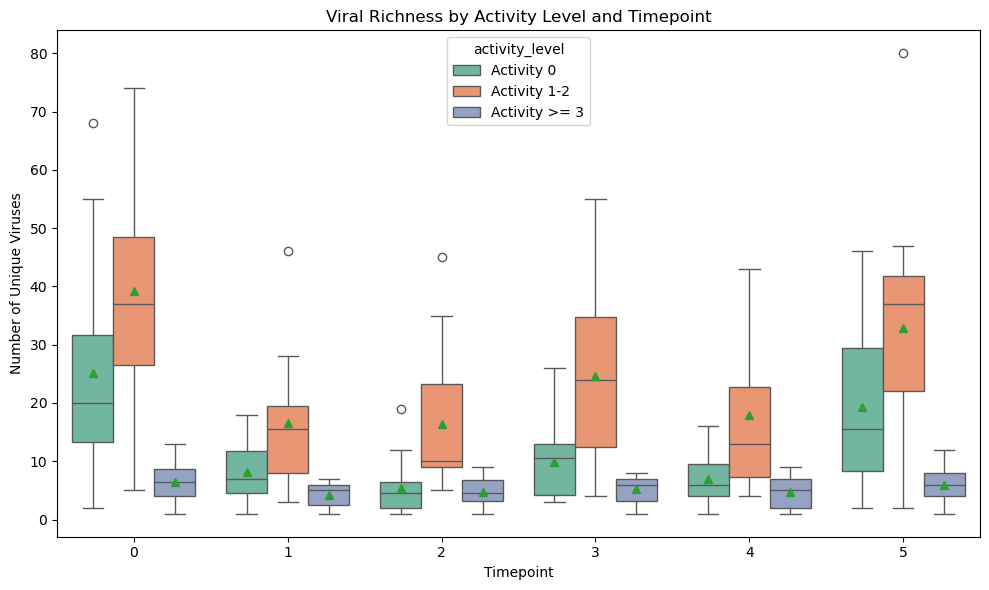

In [339]:
### Viral richness by activity level and timepoint (all samples)

# Max activity score per virus within each coassembly_group
max_activity = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('activity_score').is_not_null())
        .group_by(['coassembly_group', 'contig'])
        .agg(pl.col('activity_score').max().alias('max_activity_score'))
)

# Assign activity level to each virus instance
virus_activity = (
    max_activity
        .with_columns([
            pl.when(pl.col('max_activity_score') >= 3).then(pl.lit('Activity >= 3'))
                .when(pl.col('max_activity_score') >= 1).then(pl.lit('Activity 1-2'))
                .when(pl.col('max_activity_score') >= 0).then(pl.lit('Activity 0'))
                .otherwise(pl.lit('No Activity Data'))
                .alias('activity_level')
        ])
)

# Viral richness per sample/timepoint/activity level
virus_richness_activity = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .select(['sample', 'coassembly_group', 'timepoint', 'contig'])
        .unique()
        .join(virus_activity, on=['coassembly_group', 'contig'], how='left')
        .group_by(['sample', 'coassembly_group', 'timepoint', 'activity_level'])
        .agg(pl.col('contig').n_unique().alias('virus_richness'))
        .to_pandas()
)

# Plot richness by timepoint, colored by activity level
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=virus_richness_activity.sort_values('timepoint'),
    x='timepoint',
    y='virus_richness',
    hue='activity_level',
    order=['0', '1', '2', '3', '4', '5'],
    hue_order=['Activity 0', 'Activity 1-2', 'Activity >= 3'],
    palette='Set2',
    showmeans=True
)
plt.title('Viral Richness by Activity Level and Timepoint')
plt.xlabel('Timepoint')
plt.ylabel('Number of Unique Viruses')
# plt.yscale('log')
plt.tight_layout()
plt.show()


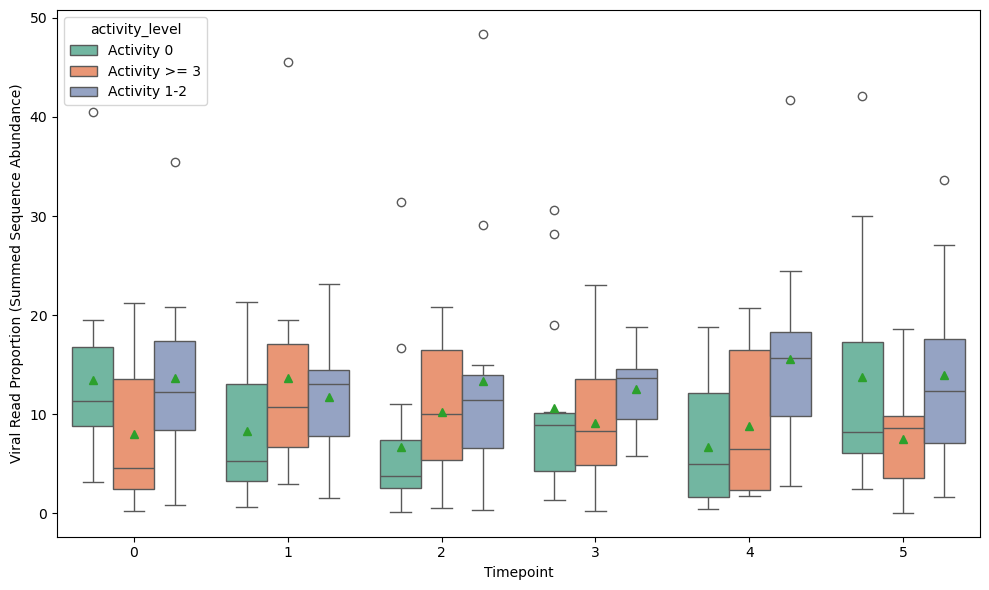

In [340]:
### Proportion of reads aligning to viruses by timepoint and clinical response

# Viral richness per sample/timepoint/activity level
abundance_viral = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .join(virus_activity, on=['coassembly_group', 'contig'], how='left')
        .group_by(['sample', 'coassembly_group', 'clinical_category', 'timepoint', 'activity_level'])
        .agg(pl.col('Taxonomic_abundance').sum().alias('viral_sequence_abundance'))
        .to_pandas()
)

# Plot proportion by timepoint and responder status
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=abundance_viral.sort_values('timepoint'),
    x='timepoint',
    y='viral_sequence_abundance',
    hue='activity_level',
    order=['0', '1', '2', '3', '4', '5'],
    palette='Set2',
    showmeans=True
)
plt.xlabel('Timepoint')
plt.ylabel('Viral Read Proportion (Summed Sequence Abundance)')
# plt.yscale('log')
plt.tight_layout()
plt.show()


In [334]:
cf_ictv_hits = pl.read_csv('../figure_6/cf_viruses_ictv_family_hits.tsv', separator='\t')
inoviruses = set(cf_ictv_hits.filter(pl.col('Family') == 'Inoviridae')['contig_id'])

tip_activity_glob = (
    tip_activity_glob
        .with_columns([
            pl.when(pl.col('contig').is_in(inoviruses)).then(pl.lit('Inoviridae'))
                .otherwise(pl.lit('Other Viruses'))
                .alias('virus_family')
        ])
)

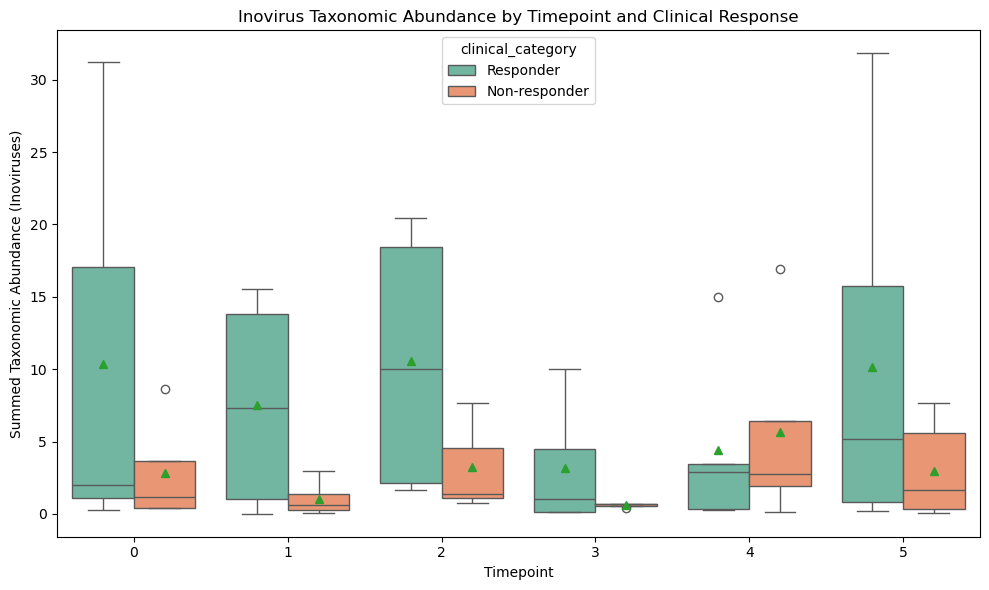

In [335]:
### Taxonomic abundance of inoviruses by timepoint and responder status

# Calculate summed taxonomic abundance of inoviruses per sample/timepoint/clinical category
inovirus_abundance = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('contig').is_in(inoviruses))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['sample', 'coassembly_group', 'timepoint', 'clinical_category'])
        .agg(pl.col('Taxonomic_abundance').sum().alias('inovirus_taxonomic_abundance'))
        .to_pandas()
)

# Plot taxonomic abundance by timepoint and responder status
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=inovirus_abundance.sort_values('timepoint'),
    x='timepoint',
    y='inovirus_taxonomic_abundance',
    hue='clinical_category',
    order=['0', '1', '2', '3', '4', '5'],
    palette='Set2',
    showmeans=True
)
plt.title('Inovirus Taxonomic Abundance by Timepoint and Clinical Response')
plt.xlabel('Timepoint')
plt.ylabel('Summed Taxonomic Abundance (Inoviruses)')
# plt.yscale('log')
plt.tight_layout()
plt.show()


Number of viruses targeting each bacterial genus by activity level:


Activity >= 3:
shape: (20, 3)
┌─────────────────┬────────────────┬─────────────┐
│ genus           ┆ activity_level ┆ num_viruses │
│ ---             ┆ ---            ┆ ---         │
│ str             ┆ str            ┆ u32         │
╞═════════════════╪════════════════╪═════════════╡
│ Streptococcus   ┆ Activity >= 3  ┆ 51          │
│ Rothia          ┆ Activity >= 3  ┆ 10          │
│ Actinomyces     ┆ Activity >= 3  ┆ 9           │
│ Veillonella     ┆ Activity >= 3  ┆ 6           │
│ Bulleidia       ┆ Activity >= 3  ┆ 5           │
│ Granulicatella  ┆ Activity >= 3  ┆ 4           │
│ Pseudomonas     ┆ Activity >= 3  ┆ 3           │
│ Pauljensenia    ┆ Activity >= 3  ┆ 3           │
│ Prevotella      ┆ Activity >= 3  ┆ 3           │
│ Gemella         ┆ Activity >= 3  ┆ 3           │
│ Escherichia     ┆ Activity >= 3  ┆ 2           │
│ Staphylococcus  ┆ Activity >= 3  ┆ 2           │
│ Porphyromonas   ┆ Activity >= 3

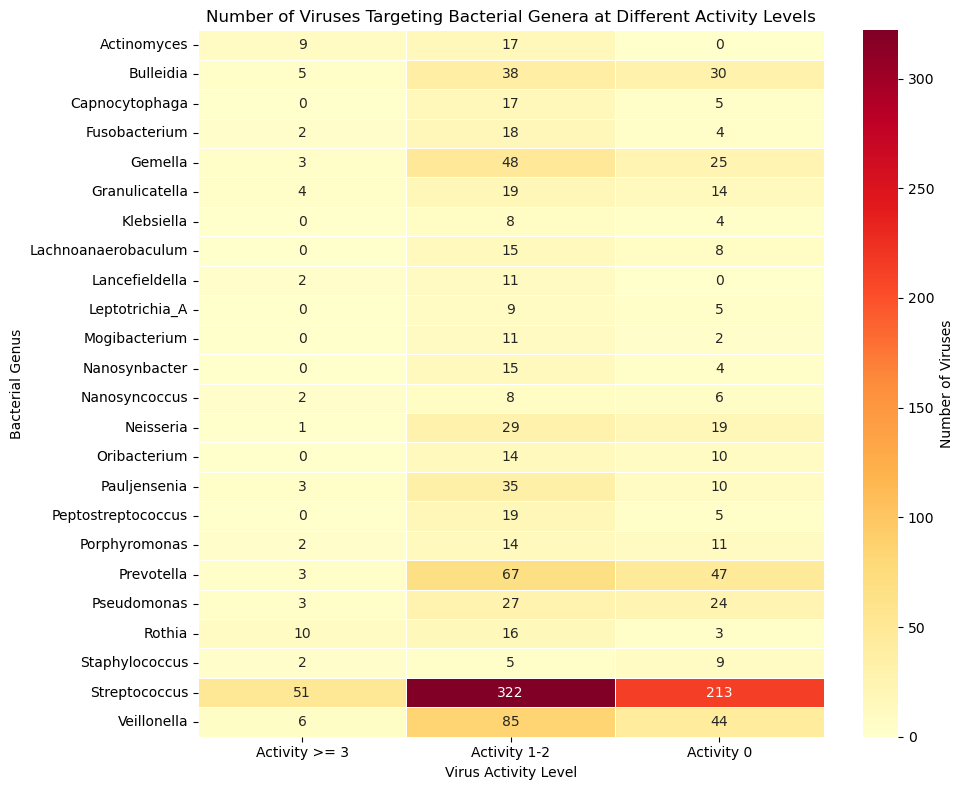

In [114]:
### Number of viruses targeting different genera by activity level

# Get max activity per virus (contig)
virus_max_activity = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('activity_score').is_not_null())
        .group_by(['contig', 'genus'])  # genus is the host genus for each virus
        .agg(pl.col('activity_score').max().alias('max_activity_score'))
)

# Assign activity levels to viruses
virus_activity_levels = (
    virus_max_activity
        .with_columns([
            pl.when(pl.col('max_activity_score') >= 3).then(pl.lit('Activity >= 3'))
                .when(pl.col('max_activity_score') >= 1).then(pl.lit('Activity 1-2'))
                .when(pl.col('max_activity_score') >= 0).then(pl.lit('Activity 0'))
                .otherwise(pl.lit('No Activity Data'))
                .alias('activity_level')
        ])
)

# Count number of unique viruses targeting each genus at each activity level
virus_counts = (
    virus_activity_levels
        .group_by(['genus', 'activity_level'])
        .agg(pl.col('contig').n_unique().alias('num_viruses'))
        .sort(['activity_level', 'num_viruses'], descending=[False, True])
)

# Display top bacteria by number of viruses at each activity level
print("Number of viruses targeting each bacterial genus by activity level:\n")
for activity in ['Activity >= 3', 'Activity 1-2', 'Activity 0']:
    subset = virus_counts.filter(pl.col('activity_level') == activity).sort('num_viruses', descending=True)
    print(f"\n{activity}:")
    print(subset.head(20))

# Create visualization: heatmap-style plot
# Get top bacteria by total viruses across all activity levels
top_bacteria = (
    virus_counts
        .group_by('genus')
        .agg(pl.col('num_viruses').sum().alias('total_viruses'))
        .sort('total_viruses', descending=True)
        .head(25)
        ['genus'].to_list()
)

# Filter for top bacteria and create plot
plot_data = virus_counts.filter(pl.col('genus').is_in(top_bacteria)).to_pandas()

plt.figure(figsize=(10, 8))
pivot_data = plot_data.pivot(index='genus', columns='activity_level', values='num_viruses').fillna(0)
pivot_data = pivot_data[['Activity >= 3', 'Activity 1-2', 'Activity 0']]  # Reorder columns

sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Number of Viruses'}, linewidths=0.5)
plt.title('Number of Viruses Targeting Bacterial Genera at Different Activity Levels')
plt.xlabel('Virus Activity Level')
plt.ylabel('Bacterial Genus')
plt.tight_layout()
plt.show()

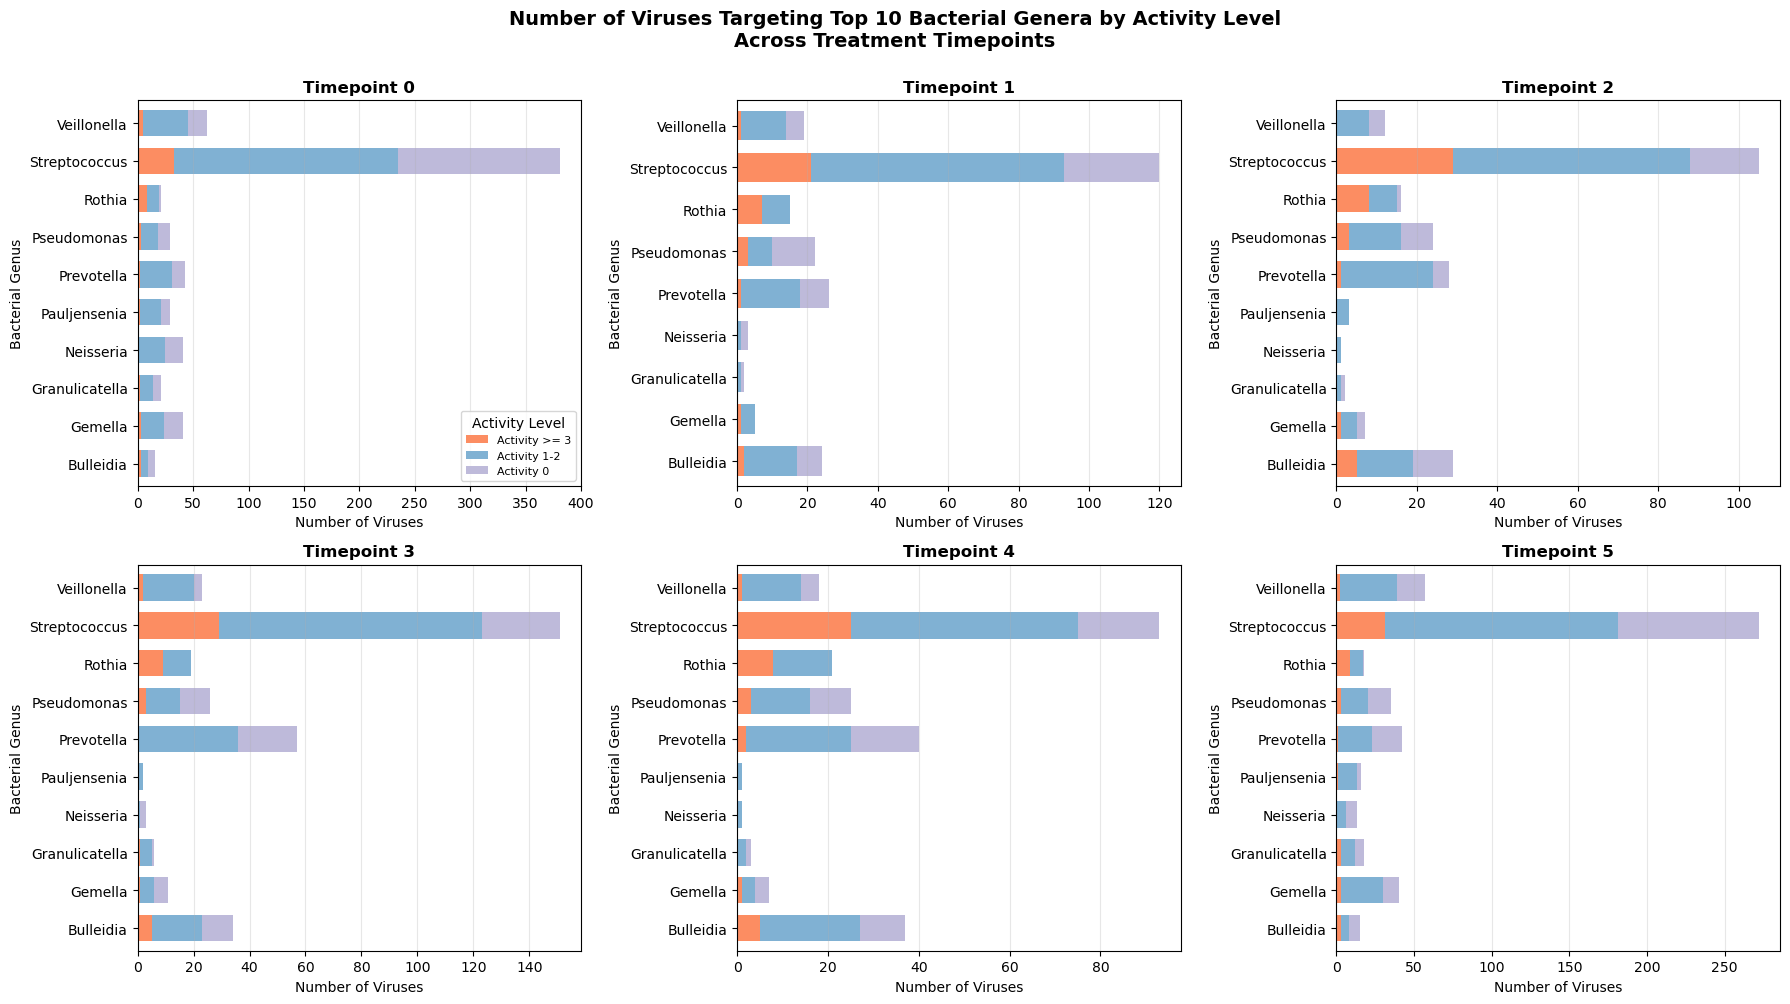

In [232]:
### Stacked bar chart of virus host genera by activity level, split by timepoint
# Get max activity per coassembly_group and contig
virus_max_activity_by_group = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('activity_score').is_not_null())
        .group_by(['coassembly_group', 'contig'])
        .agg(pl.col('activity_score').max().alias('max_activity_score'))
)

# Get unique virus-genus-timepoint combinations and join with max activity
virus_genus_timepoint = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('activity_score').is_not_null())
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .select(['coassembly_group', 'contig', 'genus', 'timepoint'])
        .unique()
        .join(virus_max_activity_by_group, on=['coassembly_group', 'contig'], how='left')
)

# Assign activity levels based on max activity within coassembly_group
virus_genus_timepoint_activity = (
    virus_genus_timepoint
        .with_columns([
            pl.when(pl.col('max_activity_score') >= 3).then(pl.lit('Activity >= 3'))
                .when(pl.col('max_activity_score') >= 1).then(pl.lit('Activity 1-2'))
                .when(pl.col('max_activity_score') >= 0).then(pl.lit('Activity 0'))
                .otherwise(pl.lit('No Activity Data'))
                .alias('activity_level')
        ])
)

# Count viruses by genus, activity level, and timepoint
virus_counts_by_tp = (
    virus_genus_timepoint_activity
        .group_by(['timepoint', 'genus', 'activity_level'])
        .agg(pl.col('contig').n_unique().alias('num_viruses'))
        .sort(['timepoint', 'activity_level', 'num_viruses'], descending=[False, False, True])
)

# Get top 10 genera by total viruses across all timepoints
top_genera = (
    virus_genus_timepoint_activity
        .select(['genus', 'contig'])
        .unique()
        .group_by('genus')
        .agg(pl.col('contig').n_unique().alias('total_viruses'))
        .sort('total_viruses', descending=True)
        .head(11)
        ['genus'].to_list()
)

# Create subplots for each timepoint
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, tp in enumerate(['0', '1', '2', '3', '4', '5']):
    # Filter for this timepoint
    tp_data = virus_counts_by_tp.filter(pl.col('timepoint') == tp).filter(pl.col('genus').is_in(top_genera)).to_pandas()
    
    if len(tp_data) > 0:
        # Pivot for stacking
        pivot_data = tp_data.pivot(index='genus', columns='activity_level', values='num_viruses').fillna(0)
        
        # Ensure all activity levels are present
        for col in ['Activity >= 3', 'Activity 1-2', 'Activity 0']:
            if col not in pivot_data.columns:
                pivot_data[col] = 0
        
        pivot_data = pivot_data[['Activity >= 3', 'Activity 1-2', 'Activity 0']]
        
        # Plot
        pivot_data.plot(kind='barh', stacked=True, ax=axes[idx], color=['#FC8D62', '#80B1D3', '#BEBADA'], width=0.7)
        axes[idx].set_title(f'Timepoint {tp}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Number of Viruses', fontsize=10)
        axes[idx].set_ylabel('Bacterial Genus', fontsize=10)
        axes[idx].grid(axis='x', alpha=0.3)
        
        if idx == 0:
            axes[idx].legend(title='Activity Level', loc='lower right', frameon=True, fontsize=8)
        else:
            axes[idx].legend().remove()
    else:
        axes[idx].text(0.5, 0.5, f'No data for TP {tp}', ha='center', va='center')
        axes[idx].set_title(f'Timepoint {tp}', fontsize=12, fontweight='bold')

plt.suptitle('Number of Viruses Targeting Top 10 Bacterial Genera by Activity Level\nAcross Treatment Timepoints', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


/tmp/ipykernel_89431/269581929.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=plot_data, x='timepoint', y='cumulative_taxonomic_abundance', hue='genus', marker='o', linewidth=2, markersize=6, ci=None)


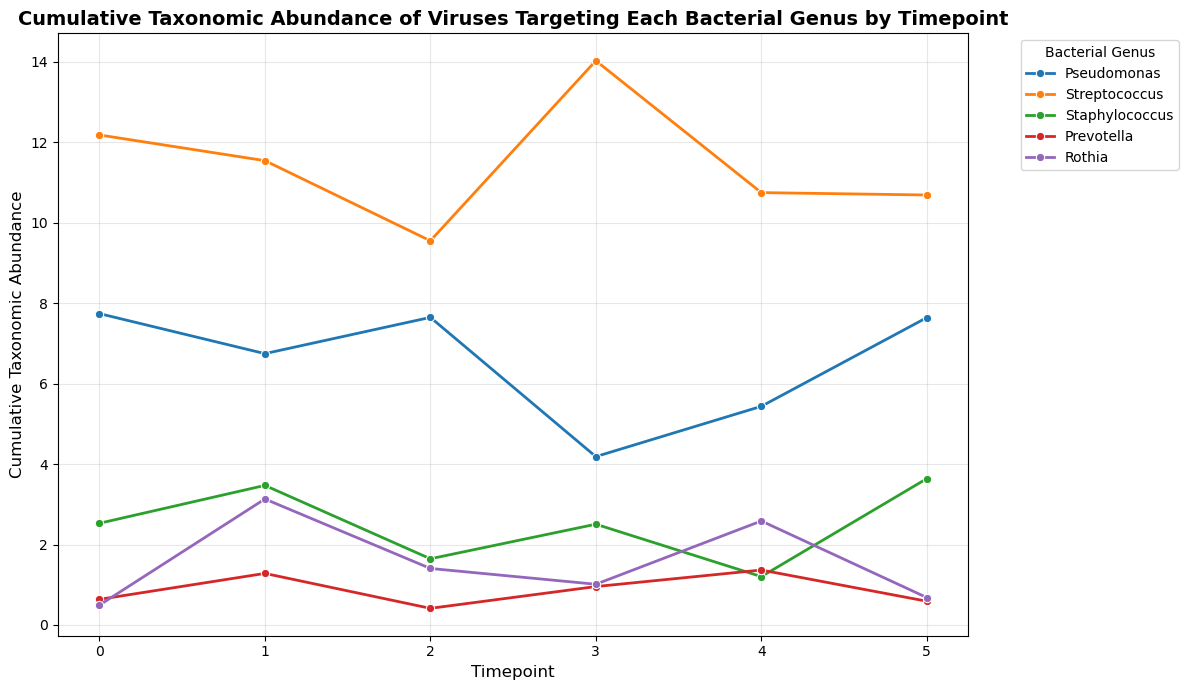

In [149]:
### Lineplot of number of viruses targeting each genus by timepoint

# Get cumulative taxonomic abundance per genus per timepoint
virus_abundance_by_genus_tp = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['genus', 'timepoint', 'coassembly_group'])
        .agg(pl.col('Taxonomic_abundance').sum().alias('cumulative_taxonomic_abundance'))
        .sort(['timepoint', 'cumulative_taxonomic_abundance'], descending=[False, True])
)

# Get top genera by total taxonomic abundance across all timepoints
top_genera_all = (
    virus_abundance_by_genus_tp
        .group_by('genus')
        .agg(pl.col('cumulative_taxonomic_abundance').sum().alias('total_abundance'))
        .sort('total_abundance', descending=True)
        .head(5)
        ['genus'].to_list()
)

# Filter for top genera and convert to pandas
plot_data = virus_abundance_by_genus_tp.filter(pl.col('genus').is_in(['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Prevotella'])).to_pandas()
plot_data['timepoint'] = plot_data['timepoint'].astype(int)

# Create lineplot
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_data, x='timepoint', y='cumulative_taxonomic_abundance', hue='genus', marker='o', linewidth=2, markersize=6, ci=None)
plt.title('Cumulative Taxonomic Abundance of Viruses Targeting Each Bacterial Genus by Timepoint', fontsize=14, fontweight='bold')
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Cumulative Taxonomic Abundance', fontsize=12)
plt.xticks([0, 1, 2, 3, 4, 5])
plt.legend(title='Bacterial Genus', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_89431/3704052534.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=plot_data, x='timepoint', y='num_viruses', hue='genus', marker='o', linewidth=2, markersize=6, ci=None)


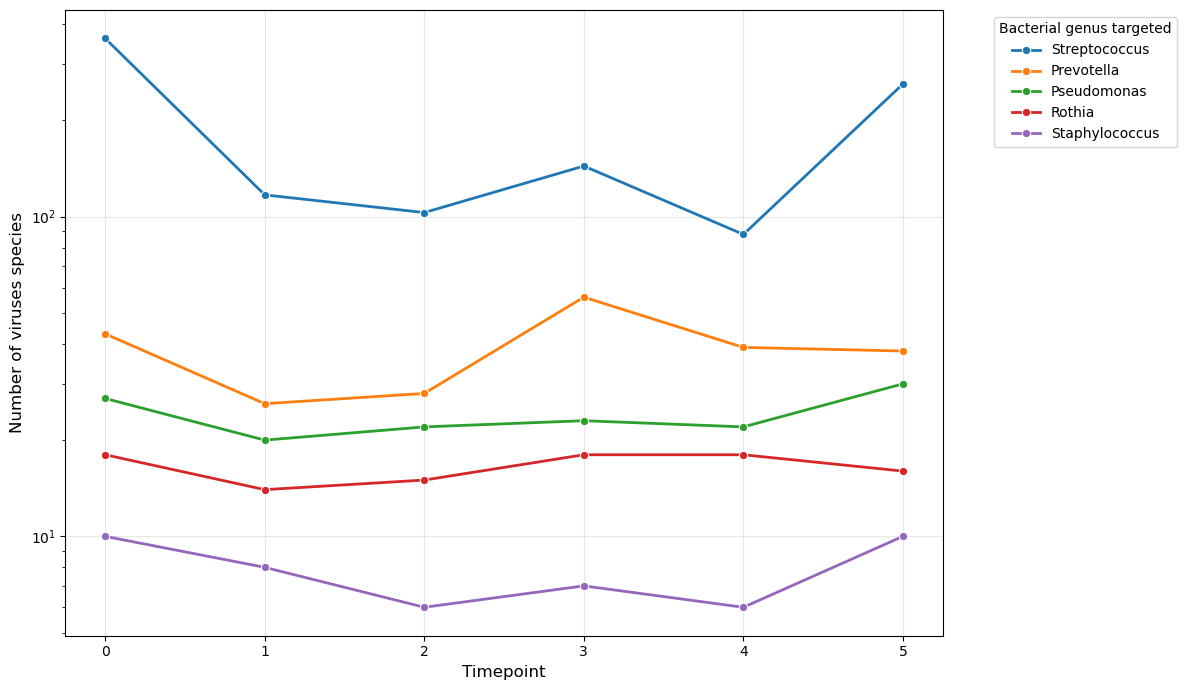

In [204]:
### Lineplot of number of viruses targeting each genus by timepoint

# Get unique viruses per genus per timepoint
virus_counts_by_genus_tp = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .select(['contig', 'genus', 'timepoint', 'coassembly_group'])
        .unique()
        .group_by(['genus', 'timepoint'])
        .agg(pl.col('contig').n_unique().alias('num_viruses'))
        .sort(['timepoint', 'num_viruses'], descending=[False, True])
)

# Get top genera by total viruses across all timepoints
top_genera_all = (
    virus_counts_by_genus_tp
        .group_by('genus')
        .agg(pl.col('num_viruses').sum().alias('total_viruses'))
        .sort('total_viruses', descending=True)
        .head(10)
        ['genus'].to_list()
)

# Filter for top genera and convert to pandas
plot_data = virus_counts_by_genus_tp.filter(pl.col('genus').is_in(['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Prevotella'])).to_pandas()
plot_data['timepoint'] = plot_data['timepoint'].astype(int)

# Create lineplot
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_data, x='timepoint', y='num_viruses', hue='genus', marker='o', linewidth=2, markersize=6, ci=None)
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Number of viruses species', fontsize=12)
plt.yscale('log')
plt.xticks([0, 1, 2, 3, 4, 5])
plt.legend(title='Bacterial genus targeted', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


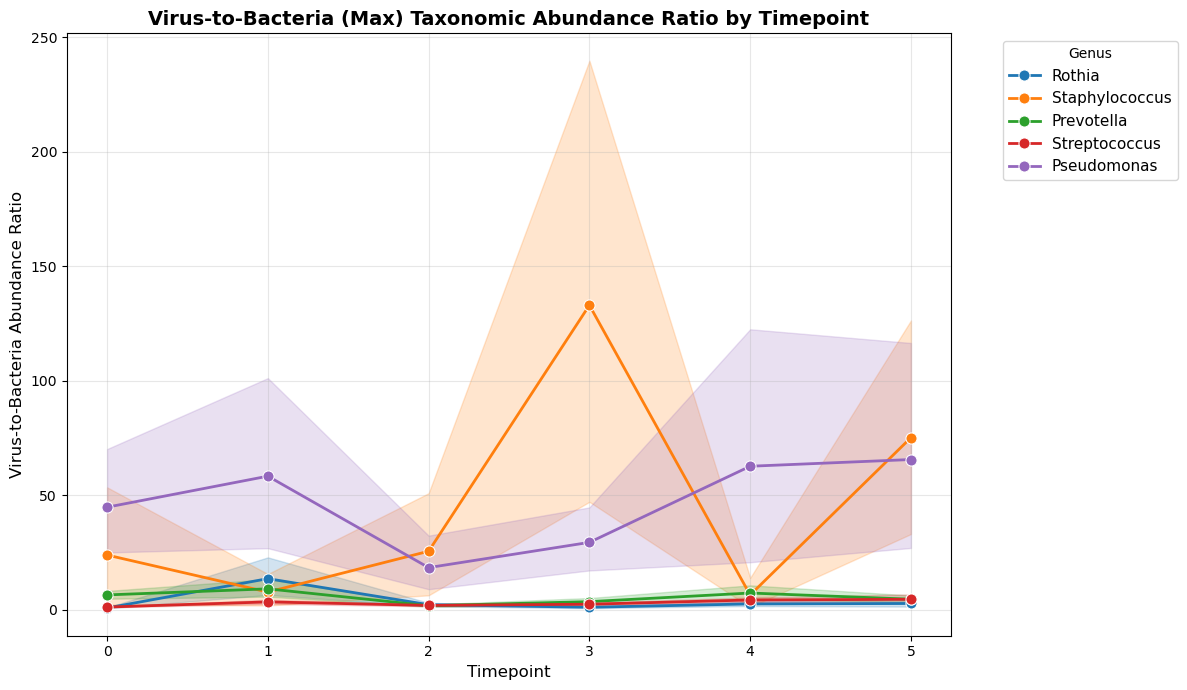

In [163]:
### Lineplot of virus-to-bacteria abundance ratio by timepoint for major genera

target_genera = ['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Prevotella']

# Max taxonomic abundance of viruses targeting each genus per timepoint
virus_max_abundance = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('genus').is_in(target_genera))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['genus', 'timepoint', 'coassembly_group'])
        .agg(pl.col('True_cov').mean().alias('mean_virus_abundance'))
)

# Max taxonomic abundance of bacteria per timepoint
bacteria_max_abundance = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(~pl.col('genome_id').str.starts_with('uhvdb'))
        .filter(pl.col('bac_genus').is_in(target_genera))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['bac_genus', 'timepoint', 'coassembly_group'])
        .agg(pl.col('True_cov').mean().alias('mean_bac_abundance'))
        .rename({'bac_genus': 'genus'})
)

# Join and compute ratio
ratio_data = (
    virus_max_abundance
        .join(bacteria_max_abundance, on=['genus', 'timepoint'], how='inner')
        .with_columns([
            (pl.col('mean_virus_abundance') / pl.col('mean_bac_abundance')).alias('virus_to_bacteria_ratio')
        ])
        .to_pandas()
)

ratio_data['timepoint'] = ratio_data['timepoint'].astype(int)

# Create lineplot
plt.figure(figsize=(12, 7))
sns.lineplot(data=ratio_data, x='timepoint', y='virus_to_bacteria_ratio', hue='genus', marker='o', linewidth=2, markersize=8)
plt.title('Virus-to-Bacteria (Max) Taxonomic Abundance Ratio by Timepoint', fontsize=14, fontweight='bold')
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Virus-to-Bacteria Abundance Ratio', fontsize=12)
plt.xticks([0, 1, 2, 3, 4, 5])
plt.legend(title='Genus', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


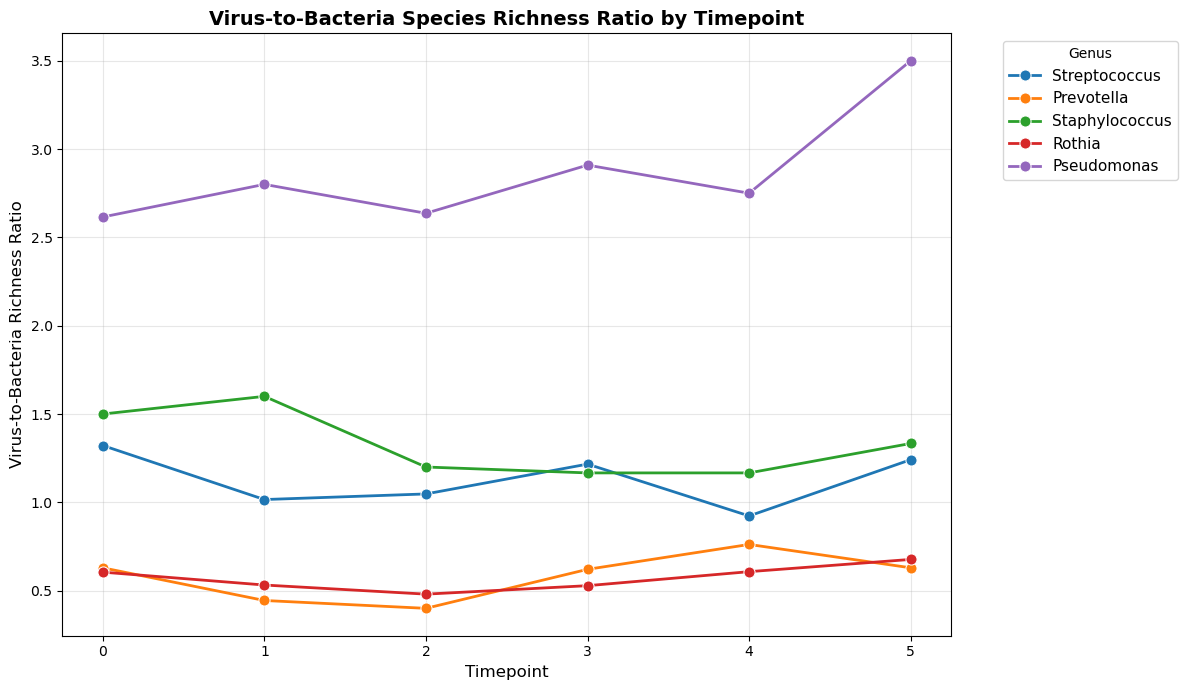

In [153]:
### Lineplot of virus-to-bacteria species richness ratio by timepoint for major genera

target_genera = ['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Prevotella']

# Number of unique viruses targeting each genus per timepoint
virus_richness = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('genus').is_in(target_genera))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .select(['genus', 'timepoint', 'coassembly_group', 'contig'])
        .unique()
        .group_by(['genus', 'timepoint', 'coassembly_group'])
        .agg(pl.col('contig').n_unique().alias('num_viruses'))
        .group_by(['genus', 'timepoint'])
        .agg(pl.col('num_viruses').mean().alias('mean_virus_richness'))
)

# Number of unique bacteria per genus per timepoint
bacteria_richness = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(~pl.col('genome_id').str.starts_with('uhvdb'))
        .filter(pl.col('bac_genus').is_in(target_genera))
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .select(['bac_genus', 'timepoint', 'coassembly_group', 'genome_id'])
        .unique()
        .group_by(['bac_genus', 'timepoint', 'coassembly_group'])
        .agg(pl.col('genome_id').n_unique().alias('num_bacteria'))
        .group_by(['bac_genus', 'timepoint'])
        .agg(pl.col('num_bacteria').mean().alias('mean_bacteria_richness'))
        .rename({'bac_genus': 'genus'})
)

# Join and compute ratio
richness_ratio_data = (
    virus_richness
        .join(bacteria_richness, on=['genus', 'timepoint'], how='inner')
        .with_columns([
            (pl.col('mean_virus_richness') / pl.col('mean_bacteria_richness')).alias('virus_to_bacteria_richness_ratio')
        ])
        .to_pandas()
)

richness_ratio_data['timepoint'] = richness_ratio_data['timepoint'].astype(int)

# Create lineplot
plt.figure(figsize=(12, 7))
sns.lineplot(data=richness_ratio_data, x='timepoint', y='virus_to_bacteria_richness_ratio', hue='genus', marker='o', linewidth=2, markersize=8)
plt.title('Virus-to-Bacteria Species Richness Ratio by Timepoint', fontsize=14, fontweight='bold')
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Virus-to-Bacteria Richness Ratio', fontsize=12)
plt.xticks([0, 1, 2, 3, 4, 5])
plt.legend(title='Genus', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_89431/2390650198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


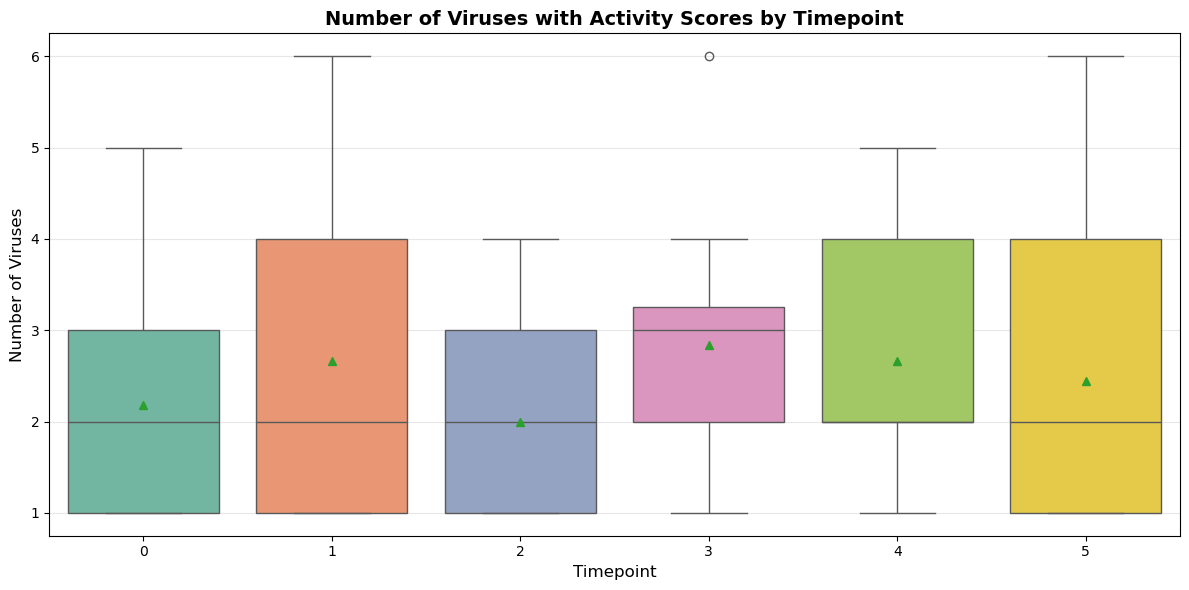

In [195]:
### Boxplot of number of viruses with activity scores by timepoint

# Count viruses with each score type per sample/timepoint
virus_scores_by_tp = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .filter((pl.col('mvirs_score') >= 1) | (pl.col('dtr_score') >= 1) | (pl.col('propagate_score') >= 1))
        .group_by(['sample', 'coassembly_group', 'timepoint'])
        .agg(pl.col('contig').n_unique().alias('num_viruses'))
)

# Combine all score types
virus_scores_df = virus_scores_by_tp.to_pandas()

# Create boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=virus_scores_df.sort_values('timepoint'),
    x='timepoint',
    y='num_viruses',
    order=['0', '1', '2', '3', '4', '5'],
    palette='Set2',
    showmeans=True
)
plt.title('Number of Viruses with Activity Scores by Timepoint', fontsize=14, fontweight='bold')
plt.xlabel('Timepoint', fontsize=12)
plt.ylabel('Number of Viruses', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


/tmp/ipykernel_89431/1973030572.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


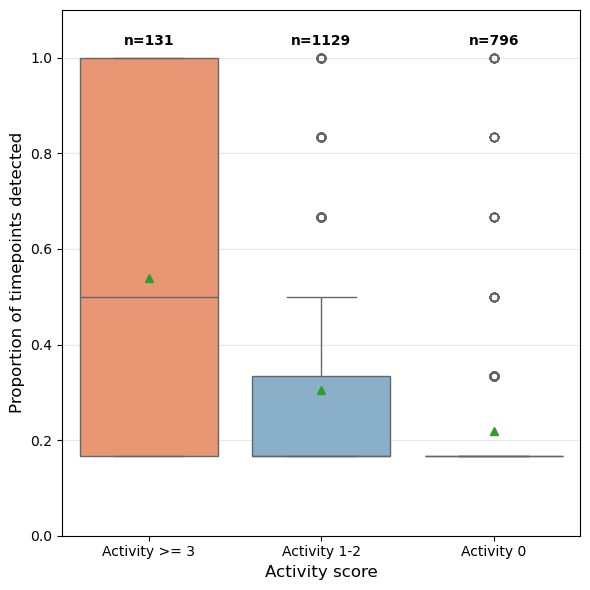

In [336]:
# Calculate persistence for each virus (proportion of timepoints detected in)
virus_persistence = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['coassembly_group', 'contig'])
        .agg([
            pl.col('timepoint').n_unique().alias('num_timepoints_detected'),
            pl.col('True_cov').mean().alias('mean_true_cov')
        ])
        # .filter(pl.col('mean_true_cov') >= 10)
        .with_columns([
            (pl.col('num_timepoints_detected') / 6).alias('persistence')
        ])
)

# Join with activity level assignment
virus_persistence_activity = (
    virus_persistence
        .join(virus_max_activity_by_group, on=['coassembly_group', 'contig'], how='left')
        .with_columns([
            pl.when(pl.col('max_activity_score') >= 3).then(pl.lit('Activity >= 3'))
                .when(pl.col('max_activity_score') >= 1).then(pl.lit('Activity 1-2'))
                .when(pl.col('max_activity_score') >= 0).then(pl.lit('Activity 0'))
                .otherwise(pl.lit('No Activity Data'))
                .alias('activity_level')
        ])
        .filter(pl.col('activity_level') != 'No Activity Data')
        .to_pandas()
)

# Create violin plot of persistence by activity level
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=virus_persistence_activity,
    x='activity_level',
    y='persistence',
    order=['Activity >= 3', 'Activity 1-2', 'Activity 0'],
    palette=['#FC8D62', '#80B1D3', '#BEBADA'],
    showmeans=True
)

# Add counts above each boxplot
activity_order = ['Activity >= 3', 'Activity 1-2', 'Activity 0']
for i, activity in enumerate(activity_order):
    count = len(virus_persistence_activity[virus_persistence_activity['activity_level'] == activity])
    ax.text(i, 1.02, f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Activity score', fontsize=12)
plt.ylabel('Proportion of timepoints detected', fontsize=12)
plt.ylim(0, 1.10)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_89431/1127961577.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


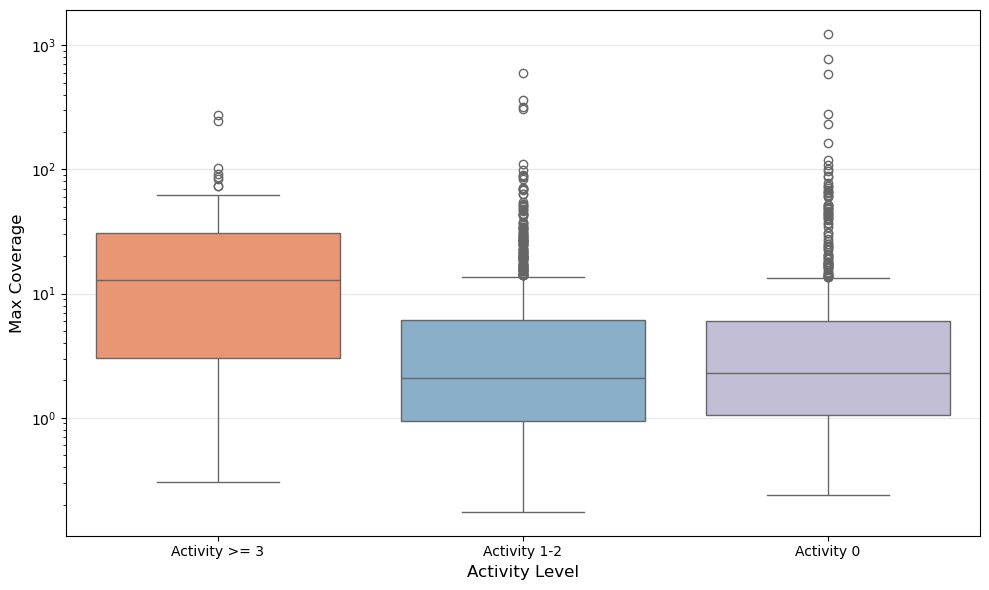

In [338]:
# Calculate persistence for each virus (proportion of timepoints detected in)
virus_persistence = (
    tip_activity_glob
        .filter(pl.col('coassembly_group').is_in(groups_w_all))
        .filter(pl.col('breadth_ratio') >= 0.6)
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .group_by(['coassembly_group', 'contig'])
        .agg(pl.col('True_cov').mean().alias('mean_cov'))
        # .filter(pl.col('mean_cov') > 10)
)

# Join with activity level assignment
virus_persistence_activity = (
    virus_persistence
        .join(virus_max_activity_by_group, on=['coassembly_group', 'contig'], how='left')
        .with_columns([
            pl.when(pl.col('max_activity_score') >= 3).then(pl.lit('Activity >= 3'))
                .when(pl.col('max_activity_score') >= 1).then(pl.lit('Activity 1-2'))
                .when(pl.col('max_activity_score') >= 0).then(pl.lit('Activity 0'))
                .otherwise(pl.lit('No Activity Data'))
                .alias('activity_level')
        ])
        .filter(pl.col('activity_level') != 'No Activity Data')
        .to_pandas()
)

# Create violin plot of persistence by activity level
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=virus_persistence_activity,
    x='activity_level',
    y='mean_cov',
    order=['Activity >= 3', 'Activity 1-2', 'Activity 0'],
    palette=['#FC8D62', '#80B1D3', '#BEBADA'],
)
plt.xlabel('Activity Level', fontsize=12)
plt.ylabel('Max Coverage', fontsize=12)
plt.yscale('log')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [227]:
from scipy.stats import wilcoxon

abund_genera = (
    tip_activity_glob
        .filter(pl.col('bac_genus').is_not_null())
        .filter(pl.col('timepoint') == '0')
        .group_by(['bac_genus'])
        .agg([
            pl.col('Sequence_abundance').mean().alias('mean_abund'),
        ])
        .filter(pl.col('mean_abund') >= 1)
        ['bac_genus']
        .unique()
)

# Compare timepoint 0 vs 1 for each genus (paired samples)
results_wilcoxon = []
for genus in abund_genera:
    genus_data = tip_activity_glob.filter(pl.col('bac_genus') == genus)
    
    # Get all unique coassembly_groups that have this genus at either timepoint
    all_groups = genus_data.select('coassembly_group').unique().sort('coassembly_group')['coassembly_group'].to_list()
    
    # Get paired data for timepoints 0 and 1
    tp0_data = genus_data.filter(pl.col('timepoint') == '0')
    tp1_data = genus_data.filter(pl.col('timepoint') == '1')
    
    # Create full paired arrays with zeros for missing groups
    tp0_vals = []
    tp1_vals = []
    
    for group in all_groups:
        tp0_abundance = tp0_data.filter(pl.col('coassembly_group') == group)['Sequence_abundance'].to_list()
        tp1_abundance = tp1_data.filter(pl.col('coassembly_group') == group)['Sequence_abundance'].to_list()
        
        tp0_vals.append(tp0_abundance[0] if tp0_abundance else 0.0)
        tp1_vals.append(tp1_abundance[0] if tp1_abundance else 0.0)
    
    # Skip if no variation between timepoints or insufficient pairs
    if len(tp0_vals) > 1 and not all(x == y for x, y in zip(tp0_vals, tp1_vals)):
        try:
            stat, pval = wilcoxon(tp0_vals, tp1_vals, method='exact')
            results_wilcoxon.append({'bac_genus': genus, 'statistic': stat, 'pvalue': pval})
        except:
            pass  # Skip if test fails

wilcoxon_df = pl.DataFrame(results_wilcoxon)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(wilcoxon_df['pvalue'].to_numpy(), method='fdr_bh')

wilcoxon_df = wilcoxon_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


In [228]:
from scipy.stats import kruskal

# Kruskal-Wallis test for timepoint 0 vs 1 (non-parametric, unpaired alternative)
results_kruskal = []
for genus in abund_genera:
    genus_data = tip_activity_glob.filter(pl.col('bac_genus') == genus)
    
    tp0_vals = genus_data.filter(pl.col('timepoint') == '0')['Sequence_abundance'].to_numpy()
    tp1_vals = genus_data.filter(pl.col('timepoint') == '1')['Sequence_abundance'].to_numpy()
    
    if len(tp0_vals) > 0 and len(tp1_vals) > 0:
        stat, pval = kruskal(tp0_vals, tp1_vals)
        results_kruskal.append({'bac_genus': genus, 'statistic': stat, 'pvalue': pval})

kruskal_df = pl.DataFrame(results_kruskal)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(kruskal_df['pvalue'].to_numpy(), method='fdr_bh')

kruskal_df = kruskal_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

# Compare results
print("Wilcoxon significant taxa:")
print(wilcoxon_df.filter(pl.col('significant_fdr')).select('bac_genus').to_series().to_list())

print("\nKruskal-Wallis significant taxa:")
print(kruskal_df.filter(pl.col('significant_fdr')).select('bac_genus').to_series().to_list())

# Find agreement
wilcoxon_sig = set(wilcoxon_df.filter(pl.col('significant_fdr')).select('bac_genus').to_series().to_list())
kruskal_sig = set(kruskal_df.filter(pl.col('significant_fdr')).select('bac_genus').to_series().to_list())

print(f"\nTaxa significant in both: {wilcoxon_sig & kruskal_sig}")
print(f"Only Wilcoxon: {wilcoxon_sig - kruskal_sig}")
print(f"Only Kruskal-Wallis: {kruskal_sig - wilcoxon_sig}")

Wilcoxon significant taxa:
['Pauljensenia', 'Rothia']

Kruskal-Wallis significant taxa:
['Rothia']

Taxa significant in both: {'Rothia'}
Only Wilcoxon: {'Pauljensenia'}
Only Kruskal-Wallis: set()


In [ ]:
### Boxplots of significant genera and Staphylococcus/Pseudomonas (mean >1% at timepoint 1)

# Get significantly different genera
sig_genera = set(wilcoxon_df.filter(pl.col('significant_fdr')).select('genus').to_series().to_list())

# Add Staphylococcus and Pseudomonas
genera_to_plot = list(sig_genera) + ['Staphylococcus', 'Pseudomonas']
genera_to_plot = list(set(genera_to_plot))  # Remove duplicates

# Filter for taxa with mean > 1% sequence abundance at timepoint 1
tp1_data = tip_activity_glob.filter(pl.col('timepoint').is_in(['1']))
tp1_above_threshold = (
    tp1_data
        .filter(pl.col('genus').is_in(genera_to_plot))
        .group_by('genus')
        .agg(pl.col('Sequence_abundance').mean().alias('mean_abundance'))
        .filter(pl.col('mean_abundance') > 1)
        .select('genus')['genus'].to_list()
)

# Filter data for these genera
plot_data = tip_activity_glob.filter(pl.col('genus').is_in(tp1_above_threshold))

# Create boxplots for each genus
for genus in sorted(tp1_above_threshold):
    genus_data = plot_data.filter(pl.col('genus') == genus).to_pandas()
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=genus_data, x='timepoint', y='Sequence_abundance', order=['0', '1', '2', '3', '4', '5'], palette='Set2', showmeans=True)
    plt.title(f'{genus} - Sequence abundance across timepoints (mean >1% at TP1)')
    plt.xlabel('Timepoint')
    plt.ylabel('Sequence Abundance')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import wilcoxon

# Compare timepoint 0 vs 1 for each genus (paired samples)
results_wilcoxon = []
for virus in tip_activity_glob.filter(pl.col('breadth_ratio') >= 0.6)['genus'].unique():
    virus_data = tip_activity_glob.filter(pl.col('contig') == virus)
    
    # Get all unique coassembly_groups that have this genus at either timepoint
    all_groups = virus_data.select('coassembly_group').unique().sort('coassembly_group')['coassembly_group'].to_list()
    
    # Get paired data for timepoints 0 and 1
    tp0_data = virus_data.filter(pl.col('timepoint') == '0')
    tp1_data = virus_data.filter(pl.col('timepoint') == '1')
    
    # Create full paired arrays with zeros for missing groups
    tp0_vals = []
    tp1_vals = []
    
    for group in all_groups:
        tp0_abundance = tp0_data.filter(pl.col('coassembly_group') == group)['Sequence_abundance'].to_list()
        tp1_abundance = tp1_data.filter(pl.col('coassembly_group') == group)['Sequence_abundance'].to_list()
        
        tp0_vals.append(tp0_abundance[0] if tp0_abundance else 0.0)
        tp1_vals.append(tp1_abundance[0] if tp1_abundance else 0.0)
    
    # Skip if no variation between timepoints or insufficient pairs
    if len(tp0_vals) > 1 and not all(x == y for x, y in zip(tp0_vals, tp1_vals)):
        try:
            stat, pval = wilcoxon(tp0_vals, tp1_vals, method='exact')
            results_wilcoxon.append({'contig': virus, 'statistic': stat, 'pvalue': pval})
        except:
            pass  # Skip if test fails

wilcoxon_df = pl.DataFrame(results_wilcoxon)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(wilcoxon_df['pvalue'].to_numpy(), method='fdr_bh')

wilcoxon_df = wilcoxon_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


In [96]:
from scipy.stats import kruskal

# Kruskal-Wallis test for timepoint 0 vs 1 (non-parametric, unpaired alternative)
results_kruskal = []
for virus in tip_activity_glob.filter(pl.col('breadth_ratio') >= 0.6)['contig'].unique():
    virus_data = tip_activity_glob.filter(pl.col('contig') == virus)
    
    tp0_vals = virus_data.filter(pl.col('timepoint') == '0')['Sequence_abundance'].to_numpy()
    tp1_vals = virus_data.filter(pl.col('timepoint') == '1')['Sequence_abundance'].to_numpy()
    
    if len(tp0_vals) > 0 and len(tp1_vals) > 0:
        stat, pval = kruskal(tp0_vals, tp1_vals)
        results_kruskal.append({'contig': virus, 'statistic': stat, 'pvalue': pval})
kruskal_df = pl.DataFrame(results_kruskal)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(kruskal_df['pvalue'].to_numpy(), method='fdr_bh')

kruskal_df = kruskal_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

# Compare results
print("Wilcoxon significant taxa:")
print(wilcoxon_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())

print("\nKruskal-Wallis significant taxa:")
print(kruskal_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())

# Find agreement
wilcoxon_sig = set(wilcoxon_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())
kruskal_sig = set(kruskal_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())
print(f"\nTaxa significant in both: {wilcoxon_sig & kruskal_sig}")
print(f"Only Wilcoxon: {wilcoxon_sig - kruskal_sig}")
print(f"Only Kruskal-Wallis: {kruskal_sig - wilcoxon_sig}")

Wilcoxon significant taxa:
[]

Kruskal-Wallis significant taxa:
[]

Taxa significant in both: set()
Only Wilcoxon: set()
Only Kruskal-Wallis: set()


In [168]:
from scipy.stats import wilcoxon

tip_virus_by_host = tip_activity_glob.filter(pl.col('breadth_ratio') >= 0.6).group_by(['genus', 'sample', 'coassembly_group', 'timepoint']).agg(pl.col('Taxonomic_abundance').sum().alias('Taxonomic_abundance'))

# Compare timepoint 0 vs 1 for each genus (paired samples)
results_wilcoxon = []
for virus in tip_virus_by_host['genus'].unique():
    virus_data = tip_virus_by_host.filter(pl.col('genus') == virus)
    
    # Get all unique coassembly_groups that have this genus at either timepoint
    all_groups = virus_data.select('coassembly_group').unique().sort('coassembly_group')['coassembly_group'].to_list()
    
    # Get paired data for timepoints 0 and 1
    tp0_data = virus_data.filter(pl.col('timepoint') == '0')
    tp1_data = virus_data.filter(pl.col('timepoint') == '1')
    
    # Create full paired arrays with zeros for missing groups
    tp0_vals = []
    tp1_vals = []
    
    for group in all_groups:
        tp0_abundance = tp0_data.filter(pl.col('coassembly_group') == group)['Taxonomic_abundance'].to_list()
        tp1_abundance = tp1_data.filter(pl.col('coassembly_group') == group)['Taxonomic_abundance'].to_list()
        
        tp0_vals.append(tp0_abundance[0] if tp0_abundance else 0.0)
        tp1_vals.append(tp1_abundance[0] if tp1_abundance else 0.0)
    
    # Skip if no variation between timepoints or insufficient pairs
    if len(tp0_vals) > 1 and not all(x == y for x, y in zip(tp0_vals, tp1_vals)):
        try:
            stat, pval = wilcoxon(tp0_vals, tp1_vals, method='exact')
            results_wilcoxon.append({'contig': virus, 'statistic': stat, 'pvalue': pval})
        except:
            pass  # Skip if test fails

wilcoxon_df = pl.DataFrame(results_wilcoxon)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(wilcoxon_df['pvalue'].to_numpy(), method='fdr_bh')

wilcoxon_df = wilcoxon_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

/tmp/ipykernel_31797/2520788408.py:8: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  virus_data = tip_virus_by_host.filter(pl.col('genus') == virus)
/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


In [172]:
from scipy.stats import kruskal

# Kruskal-Wallis test for timepoint 0 vs 1 (non-parametric, unpaired alternative)
results_kruskal = []
for virus in tip_virus_by_host['genus'].unique():
    virus_data = tip_virus_by_host.filter(pl.col('genus') == virus)
    
    tp0_vals = virus_data.filter(pl.col('timepoint') == '0')['Taxonomic_abundance'].to_numpy()
    tp1_vals = virus_data.filter(pl.col('timepoint') == '1')['Taxonomic_abundance'].to_numpy()
    
    if len(tp0_vals) > 0 and len(tp1_vals) > 0:
        stat, pval = kruskal(tp0_vals, tp1_vals)
        results_kruskal.append({'contig': virus, 'statistic': stat, 'pvalue': pval})
kruskal_df = pl.DataFrame(results_kruskal)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(kruskal_df['pvalue'].to_numpy(), method='fdr_bh')

kruskal_df = kruskal_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

# Compare results
print("Wilcoxon significant taxa:")
print(wilcoxon_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())

print("\nKruskal-Wallis significant taxa:")
print(kruskal_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())

# Find agreement
wilcoxon_sig = set(wilcoxon_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())
kruskal_sig = set(kruskal_df.filter(pl.col('significant_fdr')).select('contig').to_series().to_list())
print(f"\nTaxa significant in both: {wilcoxon_sig & kruskal_sig}")
print(f"Only Wilcoxon: {wilcoxon_sig - kruskal_sig}")
print(f"Only Kruskal-Wallis: {kruskal_sig - wilcoxon_sig}")

Wilcoxon significant taxa:
['Granulicatella', 'Bulleidia', 'Pauljensenia', 'Nanosynbacter', 'Neisseria']

Kruskal-Wallis significant taxa:
[]

Taxa significant in both: set()
Only Wilcoxon: {'Nanosynbacter', 'Pauljensenia', 'Granulicatella', 'Bulleidia', 'Neisseria'}
Only Kruskal-Wallis: set()


/tmp/ipykernel_31797/2168425251.py:6: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  virus_data = tip_virus_by_host.filter(pl.col('genus') == virus)


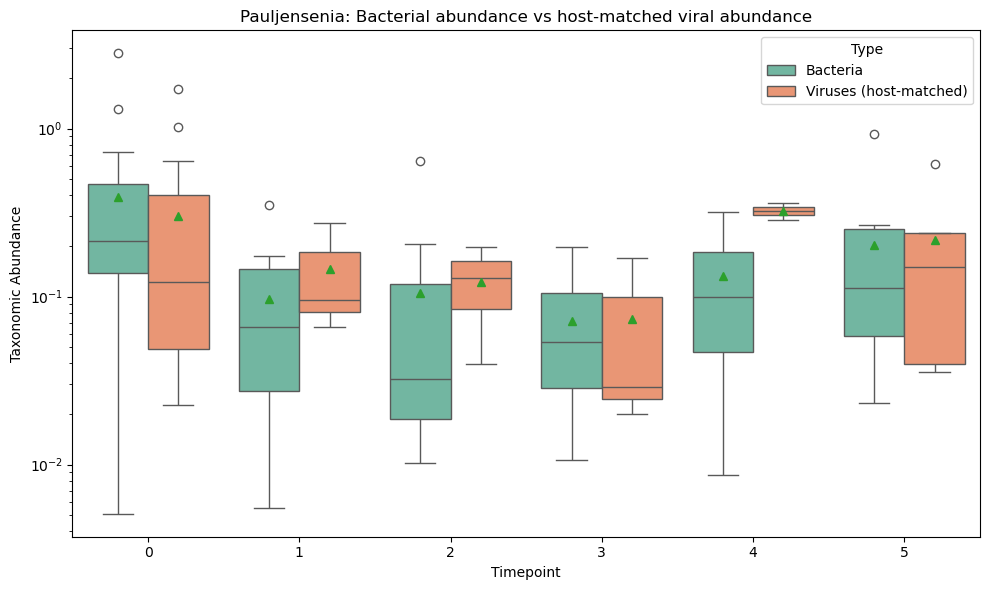

In [230]:
### Compare bacterial genus abundance vs. summed viral abundance with matching host genus

bac_genus = input("Enter bacterial genus: ")

# Bacterial genus abundance (from bac_genus)
bac_abund = (
    tip_activity_glob
        .filter(pl.col('bac_genus') == bac_genus)
        .group_by(['sample', 'coassembly_group', 'timepoint'])
        .agg(pl.col('Taxonomic_abundance').mean().alias('Taxonomic_abundance'))
        .with_columns(pl.lit('Bacteria').alias('Type'))
)

# Viral abundance for viruses whose host genus matches bac_genus
virus_abund = (
    tip_activity_glob
        .filter(pl.col('genus') == bac_genus)
        .filter(pl.col('breadth_ratio') >= 0.6)  # optional: keep only viral genomes
        .group_by(['sample', 'coassembly_group', 'timepoint'])
        .agg(pl.col('Taxonomic_abundance').mean().alias('Taxonomic_abundance'))
        .with_columns(pl.lit('Viruses (host-matched)').alias('Type'))
)

plot_df = pl.concat([bac_abund, virus_abund]).to_pandas()

# Plot side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df,
    x='timepoint',
    y='Taxonomic_abundance',
    hue='Type',
    order=['0', '1', '2', '3', '4', '5'],
    palette='Set2',
    showmeans=True
)
plt.title(f'{bac_genus}: Bacterial abundance vs host-matched viral abundance')
plt.xlabel('Timepoint')
plt.ylabel('Taxonomic Abundance')
plt.yscale('log')
plt.tight_layout()
plt.show()

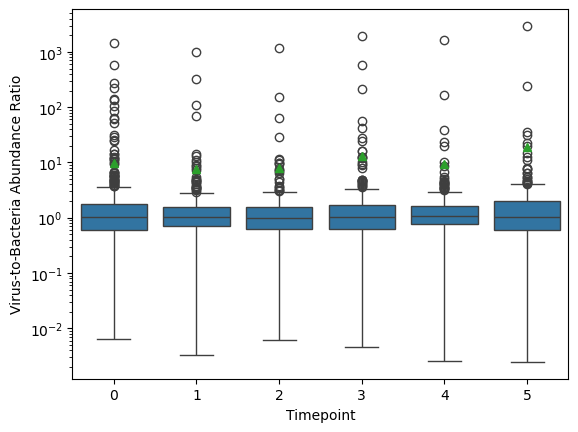

In [239]:
# Bacterial genus abundance (from bac_genus)
bac_abund = (
    tip_activity_glob
        .group_by(['sample', 'coassembly_group', 'timepoint', 'bac_genus'])
        .agg(pl.col('True_cov').max().alias('True_cov'))
        .with_columns(pl.lit('Bacteria').alias('Type'))
        .rename({'bac_genus': 'genus'})
)

# Viral abundance for viruses whose host genus matches bac_genus
virus_abund = (
    tip_activity_glob
        .filter(pl.col('breadth_ratio') >= 0.6)  # optional: keep only viral genomes
        .group_by(['sample', 'coassembly_group', 'timepoint', 'genus'])
        .agg(pl.col('True_cov').max().alias('True_cov'))
        .with_columns(pl.lit('Viruses (host-matched)').alias('Type'))
)

# join data
plot_df = (
    bac_abund.join(
        virus_abund,
        on=['sample', 'coassembly_group', 'timepoint', 'genus'],
        how='inner',
        suffix='_virus'
    )
    .with_columns([
        (pl.col('True_cov_virus')/pl.col('True_cov')).alias('virus_to_bacteria_ratio'),
    ])
)

# Plot boxplots of virus-to-bacteria ratio for each genus
sns.boxplot(plot_df.sort('timepoint').filter(pl.col('timepoint').is_in(['0', '1', '2', '3' ,'4' ,'5'])), x='timepoint', y='virus_to_bacteria_ratio', showmeans=True)
plt.xlabel('Timepoint')
plt.ylabel('Virus-to-Bacteria Abundance Ratio')
plt.yscale('log')
# hide legend
plt.show()

In [257]:
plot_df.filter(pl.col('virus_to_bacteria_ratio') > 2)

sample,coassembly_group,timepoint,genus,True_cov,Type,True_cov_virus,Type_virus,virus_to_bacteria_ratio
str,str,str,str,f64,str,f64,str,f64
"""SAMN11310302_SRR8834126_cf""","""N215""","""2""","""Pseudomonas""",8.927,"""Bacteria""",25.154,"""Viruses (host-matched)""",2.817744
"""SAMN11310247_SRR8834068_cf""","""N205""","""4""","""Streptococcus""",18.862,"""Bacteria""",83.163,"""Viruses (host-matched)""",4.409023
"""SAMN11310309_SRR8834133_cf""","""N216""","""3""","""Veillonella""",1.732,"""Bacteria""",17.571,"""Viruses (host-matched)""",10.144919
"""SAMN11310221_SRR8834042_cf""","""N201""","""3""","""Actinomyces""",6.13,"""Bacteria""",24.276,"""Viruses (host-matched)""",3.960196
"""SAMN11310239_SRR8834060_cf""","""N204""","""2""","""Pseudomonas""",0.212,"""Bacteria""",246.507,"""Viruses (host-matched)""",1162.768868
…,…,…,…,…,…,…,…,…
"""SAMN11310354_SRR8834180_cf""","""N313""","""4""","""Anaeroglobus""",0.541,"""Bacteria""",12.71,"""Viruses (host-matched)""",23.49353
"""SAMN11310225_SRR8834046_cf""","""N202""","""1""","""Pauljensenia""",0.168,"""Bacteria""",0.45,"""Viruses (host-matched)""",2.678571
"""SAMN11310296_SRR8834120_cf""","""N214""","""2""","""Pseudomonas""",16.78,"""Bacteria""",45.587,"""Viruses (host-matched)""",2.716746


In [256]:
plot_df.filter(pl.col('timepoint') == '0').filter(pl.col('virus_to_bacteria_ratio') > 2).group_by('genus').len().sort('len', descending=True).head(10)

genus,len
str,u32
"""Pseudomonas""",10
"""Neisseria""",7
"""Fusobacterium""",4
"""Bulleidia""",4
"""Nanosynbacter""",4
"""Abiotrophia""",4
"""Lancefieldella""",4
"""Actinomyces""",3
"""Prevotella""",3


/tmp/ipykernel_31797/4090828645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tip_merged_allvirus_cumabund, x='timepoint', y='Cumulative_Taxonomic_Abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'], showmeans=True)


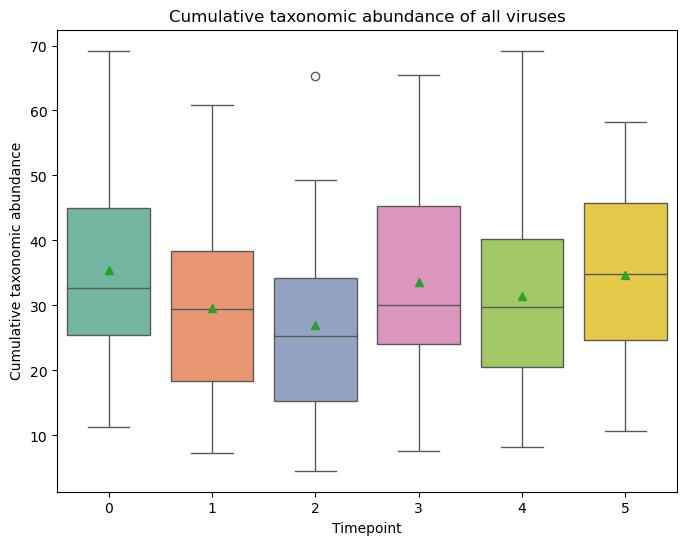

In [13]:
### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
sns.boxplot(data=tip_merged_allvirus_cumabund, x='timepoint', y='Cumulative_Taxonomic_Abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'], showmeans=True)
plt.title('Cumulative taxonomic abundance of all viruses')
plt.xlabel('Timepoint')
plt.ylabel('Cumulative taxonomic abundance')
plt.show()

/tmp/ipykernel_31797/3356889879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tip_activity_merged.filter(pl.col('Genome_file').str.contains('uhvdb')), x='timepoint', y='Taxonomic_abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'], showmeans=True)


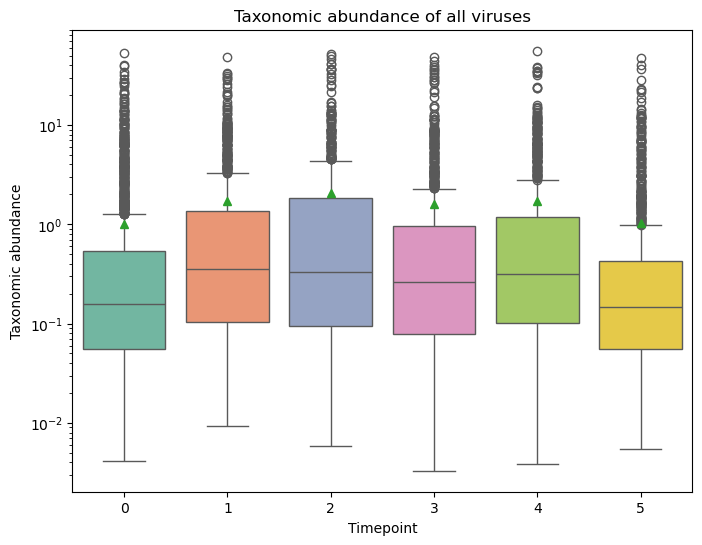

In [18]:
### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
sns.boxplot(data=tip_activity_merged.filter(pl.col('Genome_file').str.contains('uhvdb')), x='timepoint', y='Taxonomic_abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'], showmeans=True)
plt.title('Taxonomic abundance of all viruses')
plt.xlabel('Timepoint')
plt.ylabel('Taxonomic abundance')
plt.yscale('log')
plt.show()

/tmp/ipykernel_31797/1943114360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tip_merged_bac_cumabund, x='timepoint', y='Cumulative_Taxonomic_Abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'], showmeans=True)


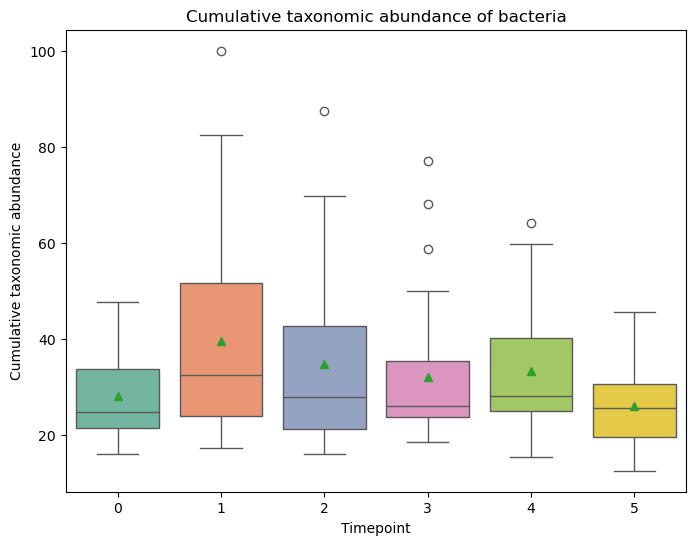

In [16]:
tip_merged_bac_cumabund = tip_merged.filter(~pl.col('Genome_file').str.contains('uhvdb')).group_by(['sample', 'coassembly_group', 'condition', 'timepoint']).agg(pl.col('Taxonomic_abundance').sum().alias('Cumulative_Taxonomic_Abundance'))

### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
sns.boxplot(data=tip_merged_bac_cumabund, x='timepoint', y='Cumulative_Taxonomic_Abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'], showmeans=True)
plt.title('Cumulative taxonomic abundance of bacteria')
plt.xlabel('Timepoint')
plt.ylabel('Cumulative taxonomic abundance')
plt.show()

/tmp/ipykernel_31797/1202095130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tip_merged.filter(~pl.col('Genome_file').str.contains('uhvdb')), x='timepoint', y='Taxonomic_abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'])


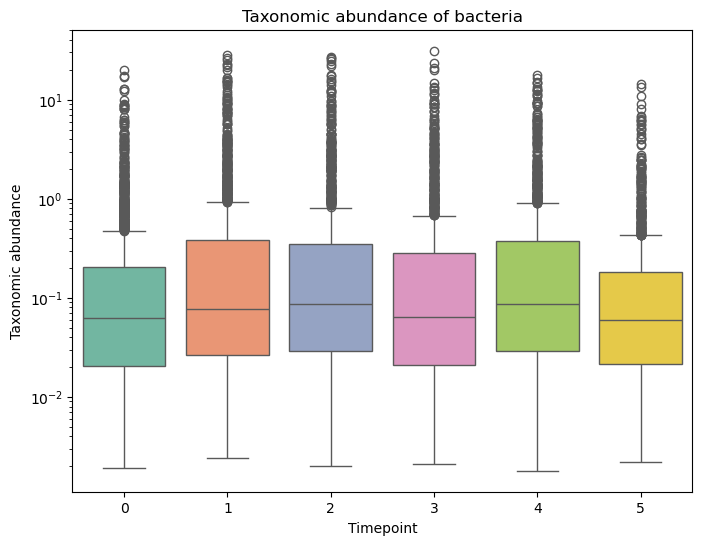

In [17]:
### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
sns.boxplot(data=tip_merged.filter(~pl.col('Genome_file').str.contains('uhvdb')), x='timepoint', y='Taxonomic_abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'])
plt.title('Taxonomic abundance of bacteria')
plt.xlabel('Timepoint')
plt.ylabel('Taxonomic abundance')
plt.yscale('log')
plt.show()

In [128]:
activity_data = pl.read_csv('../figure_6/cf_metagenome_virus_activity_data.tsv', separator='\t')

In [129]:
tip_activity_merged = tip_merged.join(activity_data[['sample_id', 'activity_score', 'ref_dtr_score', 'dtr_score', 'ref_virulent_score', 'contig_id']].rename({'sample_id': 'sample', 'contig_id': 'contig'}), on=['sample', 'contig'], how='left')

/tmp/ipykernel_99138/36484699.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tip_activity_cumabund, x='timepoint', y='Cumulative_Taxonomic_Abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'])


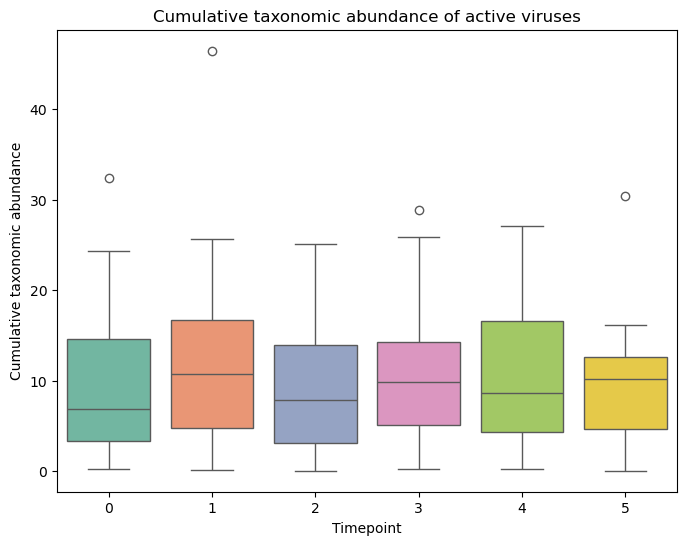

In [140]:
put_active_viruses_set = set(
    tip_activity_merged
        .group_by(['coassembly_group', 'contig'])
        .agg([
            pl.col('activity_score').max(),
        ])
        .filter(pl.col('activity_score') >= 2)
        .with_columns([
            (pl.col('coassembly_group') + "_" + pl.col('contig')).alias('group_contig')
        ])
        ['group_contig']
)

put_viruses = (
    tip_activity_merged
        .filter(
            (pl.col('coassembly_group') + "_" + pl.col('contig')).is_in(put_active_viruses_set)
        )
)

tip_activity_cumabund = put_viruses.filter(pl.col('Genome_file').str.contains('uhvdb')).group_by(['sample', 'coassembly_group', 'condition', 'timepoint']).agg(pl.col('Taxonomic_abundance').sum().alias('Cumulative_Taxonomic_Abundance'))

### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
sns.boxplot(data=tip_activity_cumabund, x='timepoint', y='Cumulative_Taxonomic_Abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'])
plt.title('Cumulative taxonomic abundance of active viruses')
plt.xlabel('Timepoint')
plt.ylabel('Cumulative taxonomic abundance')
plt.show()

/tmp/ipykernel_99138/2699820809.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=put_viruses, x='timepoint', y='Taxonomic_abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'])


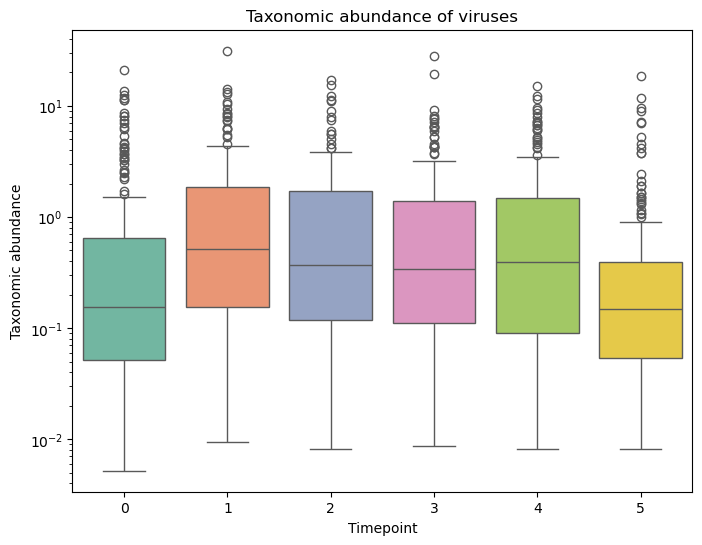

In [176]:
put_active_viruses_set = set(
    tip_activity_merged
        .group_by(['coassembly_group', 'contig'])
        .agg([
            pl.col('activity_score').max(),
        ])
        .filter(pl.col('activity_score') >= 2)
        .with_columns([
            (pl.col('coassembly_group') + "_" + pl.col('contig')).alias('group_contig')
        ])
        ['group_contig']
)

put_viruses = (
    tip_activity_merged
        .filter(
            (pl.col('coassembly_group') + "_" + pl.col('contig')).is_in(put_active_viruses_set)
        )
)

### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
sns.boxplot(data=put_viruses, x='timepoint', y='Taxonomic_abundance', palette='Set2', order=['0', '1', '2', '3', '4', '5'])
plt.title('Taxonomic abundance of viruses')
plt.xlabel('Timepoint')
plt.ylabel('Taxonomic abundance')
plt.yscale('log')
plt.show()

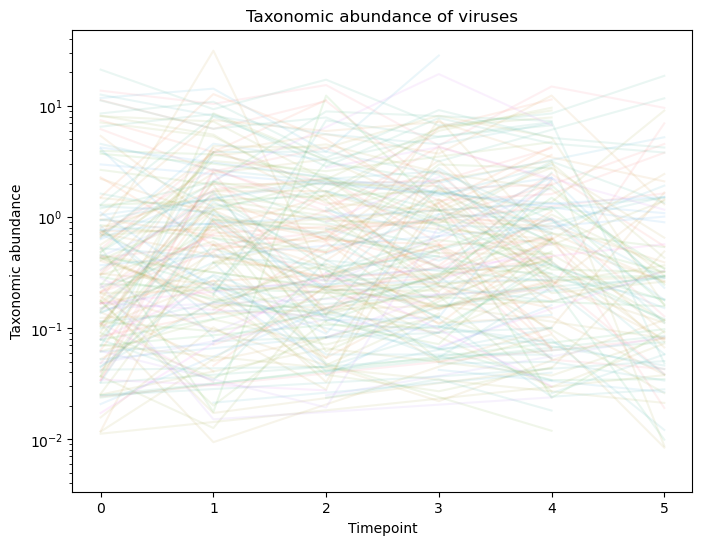

In [177]:
### Plot cumulative abundance of viruses pre, during, and post TIP
plt.figure(figsize=(8, 6))
# create a lineplot with timepoint strings ordered from 0 to 5 connecting viruses across timepoints
put_viruses2 = put_viruses.filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5'])).with_columns([
    pl.col('timepoint').cast(pl.Int32).alias('timepoint_ordered')
])
sns.lineplot(data=put_viruses2.filter(pl.col('Genome_file').str.contains('uhvdb')), x='timepoint_ordered', y='Taxonomic_abundance', hue='contig', legend=False, alpha=0.1, errorbar=None)
plt.title('Taxonomic abundance of viruses')
plt.xlabel('Timepoint')
plt.ylabel('Taxonomic abundance')
plt.yscale('log')
plt.show()

In [18]:
from scipy.stats import mannwhitneyu

### Mann-Whitney U test for bacterial genera: Responder vs Non-responder
results_mwu_bacteria = []

for genus in tip_activity_glob.filter(pl.col('bac_genus').is_not_null())['bac_genus'].unique():
    genus_data = tip_activity_glob.filter(pl.col('bac_genus') == genus).filter(pl.col('timepoint') == '0')
    
    responder_vals = genus_data.filter(
        pl.col('clinical_category') == 'Responder'
    )['Sequence_abundance'].to_numpy()
    
    non_responder_vals = genus_data.filter(
        pl.col('clinical_category') == 'Non-responder'
    )['Sequence_abundance'].to_numpy()
    
    if len(responder_vals) > 0 and len(non_responder_vals) > 0:
        stat, pval = mannwhitneyu(responder_vals, non_responder_vals, alternative='two-sided')
        results_mwu_bacteria.append({
            'bac_genus': genus,
            'statistic': stat,
            'pvalue': pval,
            'n_responder': len(responder_vals),
            'n_non_responder': len(non_responder_vals),
            'median_responder': pl.Series(responder_vals).median(),
            'median_non_responder': pl.Series(non_responder_vals).median()
        })

mwu_bacteria_df = pl.DataFrame(results_mwu_bacteria)

# Apply FDR correction
from statsmodels.stats.multitest import multipletests
rejected, fdr_pvalues, _, _ = multipletests(mwu_bacteria_df['pvalue'].to_numpy(), method='fdr_bh')

mwu_bacteria_df = mwu_bacteria_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

print("Bacterial genera with significant differential abundance (Responder vs Non-responder):")
print(mwu_bacteria_df.sort('fdr'))


Bacterial genera with significant differential abundance (Responder vs Non-responder):
shape: (73, 9)
┌────────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ bac_genus  ┆ statistic ┆ pvalue   ┆ n_respond ┆ … ┆ median_re ┆ median_no ┆ fdr      ┆ significa │
│ ---        ┆ ---       ┆ ---      ┆ er        ┆   ┆ sponder   ┆ n_respond ┆ ---      ┆ nt_fdr    │
│ str        ┆ f64       ┆ f64      ┆ ---       ┆   ┆ ---       ┆ er        ┆ f64      ┆ ---       │
│            ┆           ┆          ┆ i64       ┆   ┆ f64       ┆ ---       ┆          ┆ bool      │
│            ┆           ┆          ┆           ┆   ┆           ┆ f64       ┆          ┆           │
╞════════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ Haemophilu ┆ 482.0     ┆ 0.052787 ┆ 23        ┆ … ┆ 0.3943    ┆ 0.12775   ┆ 0.582513 ┆ false     │
│ s_D        ┆           ┆          ┆           ┆   ┆           ┆           ┆          ┆  

In [26]:
### Mann-Whitney U test for viruses (host-matched): Responder vs Non-responder
results_mwu_viruses = []

for contig in tip_activity_glob.filter(pl.col('breadth_ratio') >= 0.6)['contig'].unique():
    virus_data = tip_activity_glob.filter(pl.col('contig') == contig).filter(pl.col('timepoint') == '0')
    
    responder_vals = virus_data.filter(
        pl.col('clinical_category') == 'Responder'
    )['Taxonomic_abundance'].to_numpy()
    
    non_responder_vals = virus_data.filter(
        pl.col('clinical_category') == 'Non-responder'
    )['Taxonomic_abundance'].to_numpy()
    
    if len(responder_vals) > 0 and len(non_responder_vals) > 0:
        stat, pval = mannwhitneyu(responder_vals, non_responder_vals, alternative='two-sided')
        results_mwu_viruses.append({
            'contig': contig,
            'statistic': stat,
            'pvalue': pval,
            'n_responder': len(responder_vals),
            'n_non_responder': len(non_responder_vals),
            'median_responder': pl.Series(responder_vals).median(),
            'median_non_responder': pl.Series(non_responder_vals).median()
        })

mwu_viruses_df = pl.DataFrame(results_mwu_viruses)

# Apply FDR correction
rejected, fdr_pvalues, _, _ = multipletests(mwu_viruses_df['pvalue'].to_numpy(), method='fdr_bh')

mwu_viruses_df = mwu_viruses_df.with_columns([
    pl.Series('fdr', fdr_pvalues),
    pl.Series('significant_fdr', rejected)
])

print("Viruses with significant differential abundance (Responder vs Non-responder):")
print(mwu_viruses_df[['vcontig']].sort('pvalue'))


Viruses with significant differential abundance (Responder vs Non-responder):
shape: (141, 9)
┌─────────────┬───────────┬──────────┬────────────┬───┬────────────┬────────────┬─────┬────────────┐
│ contig      ┆ statistic ┆ pvalue   ┆ n_responde ┆ … ┆ median_res ┆ median_non ┆ fdr ┆ significan │
│ ---         ┆ ---       ┆ ---      ┆ r          ┆   ┆ ponder     ┆ _responder ┆ --- ┆ t_fdr      │
│ str         ┆ f64       ┆ f64      ┆ ---        ┆   ┆ ---        ┆ ---        ┆ f64 ┆ ---        │
│             ┆           ┆          ┆ i64        ┆   ┆ f64        ┆ f64        ┆     ┆ bool       │
╞═════════════╪═══════════╪══════════╪════════════╪═══╪════════════╪════════════╪═════╪════════════╡
│ SAMEA107409 ┆ 3.0       ┆ 0.084848 ┆ 3          ┆ … ┆ 0.0811     ┆ 0.6351     ┆ 1.0 ┆ false      │
│ 72_k141_258 ┆           ┆          ┆            ┆   ┆            ┆            ┆     ┆            │
│ 416         ┆           ┆          ┆            ┆   ┆            ┆            ┆     ┆           

/tmp/ipykernel_89431/2041348033.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=genus_data, x='clinical_category', y='Taxonomic_abundance', palette='Set2', showmeans=True)


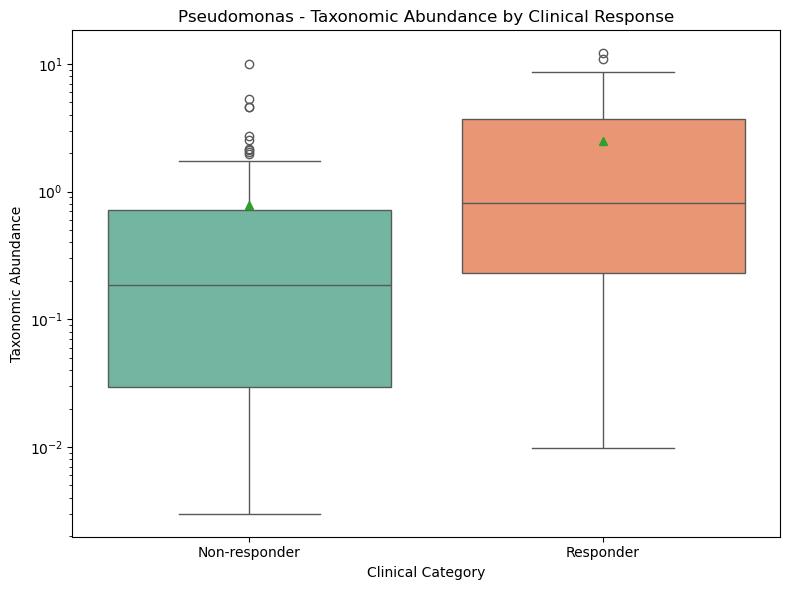

In [13]:
### Visualize significant taxa: Boxplots for responder vs non-responder

# Plot significant bacterial genera
sig_bacteria = mwu_bacteria_df.filter(pl.col('significant_fdr')).sort('fdr')['bac_genus'].to_list()

if len(sig_bacteria) > 0:
    for genus in sig_bacteria[2:3]:  # Plot top 6 significant taxa
        genus_data = tip_activity_glob.filter(pl.col('bac_genus') == genus).to_pandas()
        
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=genus_data, x='clinical_category', y='Taxonomic_abundance', palette='Set2', showmeans=True)
        plt.title(f'{genus} - Taxonomic Abundance by Clinical Response')
        plt.xlabel('Clinical Category')
        plt.ylabel('Taxonomic Abundance')
        plt.yscale('log')
        plt.tight_layout()
        plt.show()

# Plot significant viruses
sig_viruses = mwu_viruses_df.filter(pl.col('significant_fdr')).sort('fdr')['contig'].to_list()

if len(sig_viruses) > 0:
    for contig in sig_viruses[:6]:  # Plot top 6 significant taxa
        virus_data = tip_activity_glob.filter(pl.col('contig') == contig).to_pandas()
        
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=virus_data, x='clinical_category', y='Taxonomic_abundance', palette='Set2', showmeans=True)
        plt.title(f'{contig} - Taxonomic Abundance by Clinical Response')
        plt.xlabel('Clinical Category')
        plt.ylabel('Taxonomic Abundance')
        plt.yscale('log')
        plt.tight_layout()
        plt.show()
